# Análisis de tesorería y escenarios de liquidez

## Objetivo del notebook

El objetivo de este notebook es analizar la serie diaria de tesorería construida previamente y estudiar cómo cambia la posición de liquidez bajo distintos escenarios.

El notebook anterior generó dos datasets principales:

- `cash_movements.parquet`: libro único de entradas y salidas de caja;
- `gold_daily_cashflow.parquet`: serie diaria de tesorería del escenario base.

En este notebook no se modificarán los datos originales ni las reglas utilizadas para generar el escenario base.

El análisis se realizará sobre copias de dichos datasets.

## Objetivos

La fase de análisis se dividirá en varios bloques:

1. validar los datasets generados;
2. caracterizar el escenario base;
3. identificar los períodos de mayor presión de liquidez;
4. analizar la sensibilidad al saldo inicial;
5. construir un motor reproducible de escenarios;
6. estudiar retrasos sistemáticos en los cobros;
7. analizar escenarios selectivos según exposición monetaria;
8. evaluar la robustez de los resultados mediante benchmarks aleatorios y simulación Monte Carlo.

## Escenario base

El escenario base utiliza:

- fechas reales de cobro de clientes;
- importes reales de las facturas;
- salidas de caja sintéticas;
- saldo inicial sintético.

Por tanto, no representa la tesorería histórica real de una empresa concreta.

Debe interpretarse como un entorno de simulación construido sobre patrones reales de cuentas a cobrar.

## Integración posterior con el modelo de riesgo

El proyecto dispone también de un modelo predictivo de retraso en el cobro.

Sin embargo, no se aplicará directamente el modelo final sobre todo el histórico.

El modelo final fue entrenado utilizando información de períodos anteriores al test. Utilizar ese mismo modelo retrospectivamente sobre facturas pertenecientes a períodos utilizados durante su entrenamiento introduciría información futura en la simulación.

La integración entre riesgo predictivo y tesorería se realizará posteriormente utilizando únicamente predicciones compatibles con la estructura temporal del proyecto.

Esta separación permite mantener el principio de evaluación fuera de muestra utilizado durante toda la fase de modelado.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
)

CASH_MOVEMENTS_FILE = (
    PROCESSED_DIR
    / "cash_movements.parquet"
)

DAILY_CASHFLOW_FILE = (
    GOLD_DIR
    / "gold_daily_cashflow.parquet"
)

CONFIG_FILE = (
    METADATA_DIR
    / "cashflow_simulation_config.json"
)

print(
    CASH_MOVEMENTS_FILE.resolve()
)

print(
    DAILY_CASHFLOW_FILE.resolve()
)

print(
    CONFIG_FILE.resolve()
)

C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\processed\cash_movements.parquet
C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_daily_cashflow.parquet
C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\metadata\cashflow_simulation_config.json


## 1. Carga de los datasets de tesorería

El análisis parte exclusivamente de los artefactos generados y validados en `08_cashflow_simulation.ipynb`.

No se volverán a generar:

- proveedores;
- facturas;
- gastos;
- fechas de pago;
- saldo inicial.

De esta forma, el escenario base permanece congelado y puede utilizarse como referencia para comparar posteriormente todos los escenarios alternativos.

In [3]:
cash_movements = pd.read_parquet(
    CASH_MOVEMENTS_FILE
)

daily_cashflow = pd.read_parquet(
    DAILY_CASHFLOW_FILE
)

with open(
    CONFIG_FILE,
    "r",
    encoding="utf-8"
) as file:

    simulation_metadata = json.load(
        file
    )

print(
    "cash_movements:",
    cash_movements.shape
)

print(
    "daily_cashflow:",
    daily_cashflow.shape
)

cash_movements: (2777, 12)
daily_cashflow: (669, 8)


### Normalizar fechas

In [4]:
cash_movements[
    "date"
] = pd.to_datetime(
    cash_movements[
        "date"
    ]
).dt.normalize()

daily_cashflow[
    "date"
] = pd.to_datetime(
    daily_cashflow[
        "date"
    ]
).dt.normalize()

simulation_start_date = pd.Timestamp(
    simulation_metadata[
        "simulation_start_date"
    ]
)

simulation_end_date = pd.Timestamp(
    simulation_metadata[
        "simulation_end_date"
    ]
)

initial_cash_balance = float(
    simulation_metadata[
        "initial_cash_balance"
    ]
)

### Validaciones iniciales

In [5]:
dataset_checks = pd.Series({
    "cash_movements_rows": (
        len(cash_movements)
    ),

    "daily_cashflow_rows": (
        len(daily_cashflow)
    ),

    "duplicated_movement_id": (
        cash_movements[
            "movement_id"
        ]
        .duplicated()
        .sum()
    ),

    "duplicated_daily_date": (
        daily_cashflow[
            "date"
        ]
        .duplicated()
        .sum()
    ),

    "missing_movement_date": (
        cash_movements[
            "date"
        ]
        .isna()
        .sum()
    ),

    "missing_daily_date": (
        daily_cashflow[
            "date"
        ]
        .isna()
        .sum()
    ),

    "first_date": (
        daily_cashflow[
            "date"
        ].min()
    ),

    "last_date": (
        daily_cashflow[
            "date"
        ].max()
    ),
})

dataset_checks

cash_movements_rows                      2777
daily_cashflow_rows                       669
duplicated_movement_id                      0
duplicated_daily_date                       0
missing_movement_date                       0
missing_daily_date                          0
first_date                2012-02-01 00:00:00
last_date                 2013-11-30 00:00:00
dtype: object

### Assertions

In [6]:
expected_dates = pd.date_range(
    start=simulation_start_date,
    end=simulation_end_date,
    freq="D"
)

assert cash_movements[
    "movement_id"
].is_unique

assert daily_cashflow[
    "date"
].is_unique

assert daily_cashflow[
    "date"
].is_monotonic_increasing

assert (
    len(daily_cashflow)
    ==
    len(expected_dates)
)

assert (
    daily_cashflow[
        "date"
    ].reset_index(
        drop=True
    )
    ==
    pd.Series(
        expected_dates
    )
).all()

assert cash_movements[
    "date"
].between(
    simulation_start_date,
    simulation_end_date
).all()

assert np.isclose(
    daily_cashflow[
        "opening_cash_balance"
    ].iloc[0],
    initial_cash_balance
)

print(
    "✓ Datasets de tesorería validados."
)

✓ Datasets de tesorería validados.


### Validar REAL / SYNTHETIC

In [7]:
origin_check = (
    cash_movements
    .groupby(
        [
            "direction",
            "data_origin",
            "is_synthetic",
        ]
    )
    .agg(
        movement_count=(
            "movement_id",
            "count"
        ),

        total_amount=(
            "amount",
            "sum"
        ),
    )
)

display(origin_check)

assert (
    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_IN",
        "data_origin"
    ]
    == "REAL"
).all()

assert (
    cash_movements.loc[
        cash_movements[
            "direction"
        ] == "CASH_OUT",
        "data_origin"
    ]
    == "SYNTHETIC"
).all()

print(
    "✓ Origen REAL / SYNTHETIC validado."
)

,,,movement_count,total_amount
direction,data_origin,is_synthetic,,
CASH_IN,REAL,False,2366,141713.03
CASH_OUT,SYNTHETIC,True,411,106139.47


✓ Origen REAL / SYNTHETIC validado.


## 2. Diagnóstico del escenario base

Antes de construir escenarios alternativos se analizará formalmente la situación de tesorería obtenida con los movimientos originales.

Las principales métricas serán:

- saldo inicial;
- entradas acumuladas;
- salidas acumuladas;
- flujo neto;
- saldo mínimo;
- fecha del mínimo;
- saldo máximo;
- saldo final;
- días con saldo negativo;
- colchón mínimo de liquidez.

Este escenario permanecerá congelado y funcionará como referencia para todas las comparaciones posteriores.

### Resumen base

In [8]:
minimum_balance_idx = (
    daily_cashflow[
        "closing_cash_balance"
    ].idxmin()
)

maximum_balance_idx = (
    daily_cashflow[
        "closing_cash_balance"
    ].idxmax()
)

base_summary = pd.Series({
    "simulation_days": (
        len(daily_cashflow)
    ),

    "initial_cash_balance": (
        initial_cash_balance
    ),

    "total_cash_in": (
        daily_cashflow[
            "cash_in"
        ].sum()
    ),

    "total_cash_out": (
        daily_cashflow[
            "cash_out"
        ].sum()
    ),

    "net_cashflow": (
        daily_cashflow[
            "net_cashflow"
        ].sum()
    ),

    "minimum_cash_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].min()
    ),

    "minimum_balance_date": (
        daily_cashflow.loc[
            minimum_balance_idx,
            "date"
        ]
    ),

    "maximum_cash_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].max()
    ),

    "maximum_balance_date": (
        daily_cashflow.loc[
            maximum_balance_idx,
            "date"
        ]
    ),

    "final_cash_balance": (
        daily_cashflow[
            "closing_cash_balance"
        ].iloc[-1]
    ),

    "negative_cash_days": (
        daily_cashflow[
            "closing_cash_balance"
        ]
        .lt(0)
        .sum()
    ),
})

base_summary

simulation_days                         669
initial_cash_balance            7236.782045
total_cash_in                     141713.03
total_cash_out                    106139.47
net_cashflow                       35573.56
minimum_cash_balance            6865.132045
minimum_balance_date    2012-03-02 00:00:00
maximum_cash_balance           43633.722045
maximum_balance_date    2013-11-28 00:00:00
final_cash_balance             42810.342045
negative_cash_days                        0
dtype: object

### Evolucion diaria

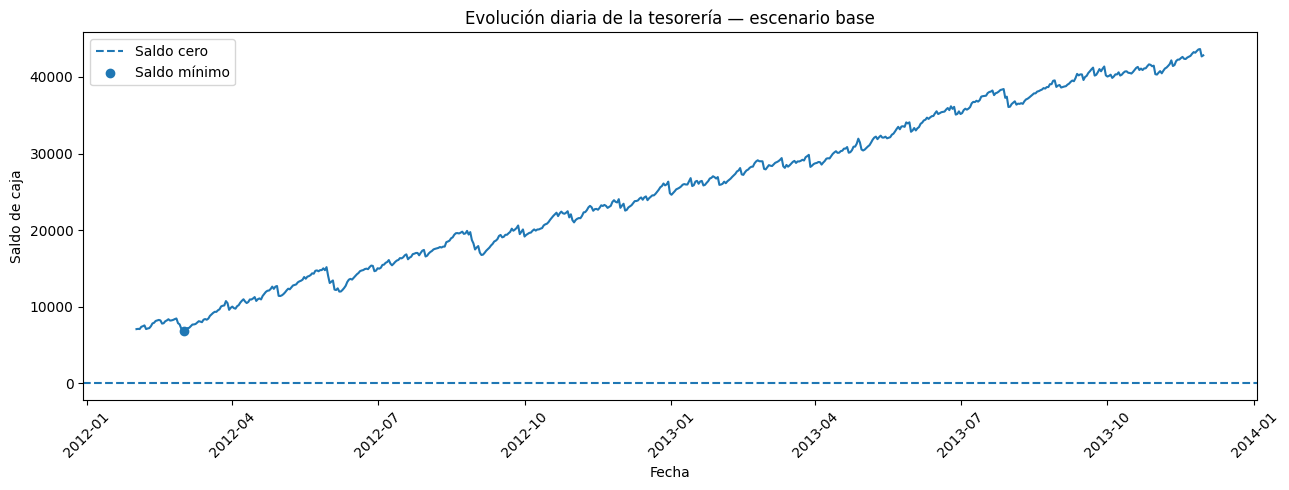

In [9]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.plot(
    daily_cashflow[
        "date"
    ],
    daily_cashflow[
        "closing_cash_balance"
    ]
)

ax.axhline(
    0,
    linestyle="--",
    label="Saldo cero"
)

ax.scatter(
    daily_cashflow.loc[
        minimum_balance_idx,
        "date"
    ],
    daily_cashflow.loc[
        minimum_balance_idx,
        "closing_cash_balance"
    ],
    label="Saldo mínimo"
)

ax.set_title(
    "Evolución diaria de la tesorería — escenario base"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Resumen mensual

In [10]:
monthly_cashflow = (
    daily_cashflow
    .set_index(
        "date"
    )
    .resample("MS")
    .agg(
        cash_in=(
            "cash_in",
            "sum"
        ),

        cash_out=(
            "cash_out",
            "sum"
        ),

        net_cashflow=(
            "net_cashflow",
            "sum"
        ),

        minimum_balance=(
            "closing_cash_balance",
            "min"
        ),

        maximum_balance=(
            "closing_cash_balance",
            "max"
        ),

        closing_balance=(
            "closing_cash_balance",
            "last"
        ),
    )
)

monthly_cashflow

,cash_in,cash_out,net_cashflow,minimum_balance,maximum_balance,closing_balance
date,,,,,,
2012-02-01,4807.34,4878.63,-71.29,7080.062045,8468.532045,7165.492045
2012-03-01,6562.75,3870.45,2692.30,6865.132045,10737.582045,9857.792045
2012-04-01,6243.57,4677.15,1566.42,9751.542045,12707.742045,11424.212045
2012-05-01,6743.34,4142.48,2600.86,11400.122045,15168.192045,14025.072045
2012-06-01,6113.82,5426.09,687.73,11976.812045,15372.222045,14712.802045
2012-07-01,6094.49,4249.62,1844.87,14965.932045,17417.802045,16557.672045
2012-08-01,6064.65,5146.67,917.98,16657.752045,19899.882045,17475.652045
2012-09-01,6986.54,4373.80,2612.74,16755.792045,20603.272045,20088.392045
2012-10-01,6726.75,5525.27,1201.48,19163.222045,22465.182045,21289.872045


### Visualizar entradas y salidas mensuales

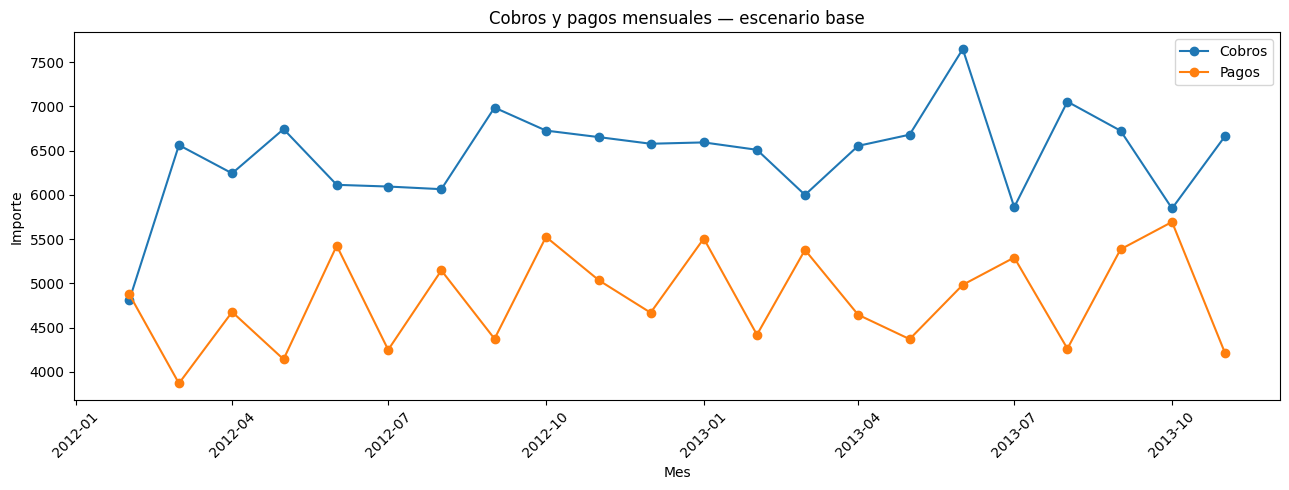

In [11]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.plot(
    monthly_cashflow.index,
    monthly_cashflow[
        "cash_in"
    ],
    marker="o",
    label="Cobros"
)

ax.plot(
    monthly_cashflow.index,
    monthly_cashflow[
        "cash_out"
    ],
    marker="o",
    label="Pagos"
)

ax.set_title(
    "Cobros y pagos mensuales — escenario base"
)

ax.set_xlabel(
    "Mes"
)

ax.set_ylabel(
    "Importe"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Meses con flujo de caja neto negativo

In [12]:
negative_months = (
    monthly_cashflow[
        monthly_cashflow[
            "net_cashflow"
        ] < 0
    ]
    .copy()
)

print(
    "Meses con flujo neto negativo:",
    len(negative_months)
)

negative_months

Meses con flujo neto negativo: 1


,cash_in,cash_out,net_cashflow,minimum_balance,maximum_balance,closing_balance
date,,,,,,
2012-02-01,4807.34,4878.63,-71.29,7080.062045,8468.532045,7165.492045


### Dias de mayor presion

In [13]:
largest_outflow_days = (
    daily_cashflow[
        [
            "date",
            "cash_out",
            "cash_in",
            "net_cashflow",
            "opening_cash_balance",
            "closing_cash_balance",
        ]
    ]
    .sort_values(
        "cash_out",
        ascending=False
    )
    .head(10)
)

display(largest_outflow_days)

largest_negative_cashflow_days = (
    daily_cashflow[
        [
            "date",
            "cash_in",
            "cash_out",
            "net_cashflow",
            "opening_cash_balance",
            "closing_cash_balance",
        ]
    ]
    .sort_values(
        "net_cashflow"
    )
    .head(10)
)

largest_negative_cashflow_days

,date,cash_out,cash_in,net_cashflow,opening_cash_balance,closing_cash_balance
422,2013-03-29,1697.80,124.38,-1573.42,29824.522045,28251.102045
334,2012-12-31,1634.81,126.50,-1508.31,26327.102045,24818.792045
89,2012-04-30,1487.78,204.25,-1283.53,12707.742045,11424.212045
240,2012-09-28,1467.87,343.80,-1124.07,20603.272045,19479.202045
303,2012-11-30,1462.82,329.77,-1133.05,24042.622045,22909.572045
546,2013-07-31,1428.26,78.88,-1349.38,37418.232045,36068.852045
607,2013-09-30,1378.88,223.45,-1155.43,41355.052045,40199.622045
124,2012-06-04,1313.11,126.35,-1186.76,13430.642045,12243.882045
348,2013-01-14,1306.32,271.79,-1034.53,26786.582045,25752.052045
365,2013-01-31,1279.86,258.55,-1021.31,26926.102045,25904.792045


,date,cash_in,cash_out,net_cashflow,opening_cash_balance,closing_cash_balance
422,2013-03-29,124.38,1697.80,-1573.42,29824.522045,28251.102045
334,2012-12-31,126.50,1634.81,-1508.31,26327.102045,24818.792045
546,2013-07-31,78.88,1428.26,-1349.38,37418.232045,36068.852045
89,2012-04-30,204.25,1487.78,-1283.53,12707.742045,11424.212045
485,2013-05-31,7.47,1242.35,-1234.88,34070.232045,32835.352045
124,2012-06-04,126.35,1313.11,-1186.76,13430.642045,12243.882045
607,2013-09-30,223.45,1378.88,-1155.43,41355.052045,40199.622045
544,2013-07-29,90.62,1240.39,-1149.77,38416.282045,37266.512045
120,2012-05-31,100.85,1243.97,-1143.12,15168.192045,14025.072045
303,2012-11-30,329.77,1462.82,-1133.05,24042.622045,22909.572045


## 3. Colchón de liquidez del escenario base

El saldo mínimo observado depende tanto de los movimientos de caja como del saldo disponible al inicio.

Para separar ambos componentes se calculará el saldo inicial mínimo que habría sido necesario para evitar entrar en caja negativa manteniendo exactamente los mismos cobros y pagos.

Esta métrica permite responder a una pregunta distinta de la utilizada para construir la simulación:

> ¿qué colchón inicial mínimo habría necesitado la empresa para atravesar este histórico sin presentar un saldo negativo?

No representa una recomendación empresarial de caja mínima.

Se trata únicamente de una medida retrospectiva de sensibilidad aplicada al escenario simulado.

### Saldo inicial minimo necesario

In [14]:
minimum_cumulative_net_cashflow = (
    daily_cashflow[
        "cumulative_net_cashflow"
    ].min()
)

minimum_required_initial_cash = max(
    0.0,
    -minimum_cumulative_net_cashflow
)

average_monthly_cash_out = (
    monthly_cashflow[
        "cash_out"
    ].mean()
)

liquidity_buffer_summary = pd.Series({
    "configured_initial_cash": (
        initial_cash_balance
    ),

    "minimum_required_initial_cash": (
        minimum_required_initial_cash
    ),

    "initial_cash_excess_vs_minimum": (
        initial_cash_balance
        - minimum_required_initial_cash
    ),

    "average_monthly_cash_out": (
        average_monthly_cash_out
    ),

    "configured_initial_cash_months": (
        initial_cash_balance
        /
        average_monthly_cash_out
    ),

    "minimum_required_cash_months": (
        minimum_required_initial_cash
        /
        average_monthly_cash_out
    ),
})

liquidity_buffer_summary

configured_initial_cash           7236.782045
minimum_required_initial_cash      371.650000
initial_cash_excess_vs_minimum    6865.132045
average_monthly_cash_out          4824.521364
configured_initial_cash_months       1.500000
minimum_required_cash_months         0.077034
dtype: float64

## 4. Motor de escenarios

Los escenarios alternativos no modificarán el dataset base.

Cada escenario se construirá a partir de una copia de `cash_movements` y producirá una nueva serie diaria de tesorería.

De esta forma:

- el escenario base permanece inmutable;
- cada modificación puede documentarse de forma explícita;
- todos los escenarios utilizan las mismas métricas;
- las comparaciones son reproducibles.

El motor recibirá:

- un libro de movimientos;
- un saldo inicial;
- una fecha de inicio;
- una fecha de fin.

Y devolverá una serie diaria con:

- entradas;
- salidas;
- flujo neto;
- flujo acumulado;
- saldo inicial diario;
- saldo final diario.

### Funcion para reconstruir tesoreria

In [15]:
def build_daily_cashflow(
    movements,
    initial_cash,
    start_date,
    end_date,
):
    movements = (
        movements
        .copy()
    )

    movements[
        "date"
    ] = pd.to_datetime(
        movements[
            "date"
        ]
    ).dt.normalize()

    calendar = pd.DataFrame({
        "date": pd.date_range(
            start=start_date,
            end=end_date,
            freq="D"
        )
    })

    daily_in = (
        movements.loc[
            movements[
                "direction"
            ] == "CASH_IN"
        ]
        .groupby(
            "date"
        )["amount"]
        .sum()
    )

    daily_out = (
        movements.loc[
            movements[
                "direction"
            ] == "CASH_OUT"
        ]
        .groupby(
            "date"
        )["amount"]
        .sum()
    )

    movement_count = (
        movements
        .groupby(
            "date"
        )["movement_id"]
        .count()
    )

    calendar[
        "cash_in"
    ] = (
        calendar[
            "date"
        ]
        .map(
            daily_in
        )
        .fillna(0.0)
    )

    calendar[
        "cash_out"
    ] = (
        calendar[
            "date"
        ]
        .map(
            daily_out
        )
        .fillna(0.0)
    )

    calendar[
        "movement_count"
    ] = (
        calendar[
            "date"
        ]
        .map(
            movement_count
        )
        .fillna(0)
        .astype(int)
    )

    calendar[
        "net_cashflow"
    ] = (
        calendar[
            "cash_in"
        ]
        -
        calendar[
            "cash_out"
        ]
    )

    calendar[
        "cumulative_net_cashflow"
    ] = (
        calendar[
            "net_cashflow"
        ].cumsum()
    )

    calendar[
        "closing_cash_balance"
    ] = (
        initial_cash
        +
        calendar[
            "cumulative_net_cashflow"
        ]
    )

    calendar[
        "opening_cash_balance"
    ] = (
        calendar[
            "closing_cash_balance"
        ]
        .shift(1)
    )

    calendar.loc[
        0,
        "opening_cash_balance"
    ] = initial_cash

    return calendar[
        [
            "date",
            "opening_cash_balance",
            "cash_in",
            "cash_out",
            "net_cashflow",
            "closing_cash_balance",
            "cumulative_net_cashflow",
            "movement_count",
        ]
    ]

### Validar el motor contra el escenario original

In [16]:
reconstructed_base = (
    build_daily_cashflow(
        movements=cash_movements,
        initial_cash=initial_cash_balance,
        start_date=simulation_start_date,
        end_date=simulation_end_date,
    )
)

assert np.allclose(
    reconstructed_base[
        "cash_in"
    ],
    daily_cashflow[
        "cash_in"
    ]
)

assert np.allclose(
    reconstructed_base[
        "cash_out"
    ],
    daily_cashflow[
        "cash_out"
    ]
)

assert np.allclose(
    reconstructed_base[
        "closing_cash_balance"
    ],
    daily_cashflow[
        "closing_cash_balance"
    ]
)

print(
    "✓ Motor de escenarios reproduce exactamente "
    "el escenario base."
)

✓ Motor de escenarios reproduce exactamente el escenario base.


### Funcion de metricas por escenario

In [17]:
def calculate_scenario_metrics(
    daily_df,
    scenario_name,
    initial_cash,
):
    minimum_idx = (
        daily_df[
            "closing_cash_balance"
        ].idxmin()
    )

    negative_mask = (
        daily_df[
            "closing_cash_balance"
        ] < 0
    )

    first_negative_date = (
        daily_df.loc[
            negative_mask,
            "date"
        ].min()
        if negative_mask.any()
        else pd.NaT
    )

    minimum_balance = (
        daily_df[
            "closing_cash_balance"
        ].min()
    )

    return {
        "scenario": (
            scenario_name
        ),

        "initial_cash": (
            initial_cash
        ),

        "total_cash_in": (
            daily_df[
                "cash_in"
            ].sum()
        ),

        "total_cash_out": (
            daily_df[
                "cash_out"
            ].sum()
        ),

        "net_cashflow": (
            daily_df[
                "net_cashflow"
            ].sum()
        ),

        "minimum_balance": (
            minimum_balance
        ),

        "minimum_balance_date": (
            daily_df.loc[
                minimum_idx,
                "date"
            ]
        ),

        "final_balance": (
            daily_df[
                "closing_cash_balance"
            ].iloc[-1]
        ),

        "negative_cash_days": (
            negative_mask.sum()
        ),

        "first_negative_date": (
            first_negative_date
        ),

        "maximum_funding_gap": (
            max(
                0.0,
                -minimum_balance
            )
        ),
    }

## 5. Sensibilidad al saldo inicial

El primer análisis de sensibilidad mantendrá exactamente los mismos cobros y pagos.

La única variable modificada será el saldo disponible al inicio de la simulación.

Esto permitirá estudiar cuánto depende la estabilidad de caja del colchón inicial.

Los escenarios se expresarán como múltiplos de la salida mensual media.

Se analizarán:

- 0 meses;
- 0,05 meses;
- 0,10 meses;
- 0,25 meses;
- 0,50 meses;
- 1,00 mes;
- 1,50 meses.

El escenario de 1,50 meses corresponde aproximadamente a la configuración utilizada en la simulación base.

Este análisis no pretende seleccionar retrospectivamente un saldo óptimo.

Su finalidad es medir la sensibilidad de la liquidez a diferentes niveles de caja inicial.

### Ejecutar sensibilidad

In [18]:
initial_cash_month_scenarios = [
    0.00,
    0.05,
    0.10,
    0.25,
    0.50,
    1.00,
    1.50,
]

initial_cash_scenario_rows = []

initial_cash_scenario_daily = {}

for months_of_cash in (
    initial_cash_month_scenarios
):

    scenario_initial_cash = (
        average_monthly_cash_out
        * months_of_cash
    )

    scenario_name = (
        f"INITIAL_CASH_"
        f"{months_of_cash:.2f}_MONTHS"
    )

    scenario_daily = (
        build_daily_cashflow(
            movements=cash_movements,
            initial_cash=scenario_initial_cash,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    initial_cash_scenario_daily[
        scenario_name
    ] = scenario_daily

    initial_cash_scenario_rows.append(
        calculate_scenario_metrics(
            daily_df=scenario_daily,
            scenario_name=scenario_name,
            initial_cash=scenario_initial_cash,
        )
    )

initial_cash_sensitivity = (
    pd.DataFrame(
        initial_cash_scenario_rows
    )
)

initial_cash_sensitivity

,scenario,initial_cash,total_cash_in,total_cash_out,net_cashflow,minimum_balance,minimum_balance_date,final_balance,negative_cash_days,first_negative_date,maximum_funding_gap
0,INITIAL_CASH_0.00_MONTHS,0.000000,141713.03,106139.47,35573.56,-371.650000,2012-03-02,35573.560000,11,2012-02-01,371.650000
1,INITIAL_CASH_0.05_MONTHS,241.226068,141713.03,106139.47,35573.56,-130.423932,2012-03-02,35814.786068,2,2012-03-01,130.423932
2,INITIAL_CASH_0.10_MONTHS,482.452136,141713.03,106139.47,35573.56,110.802136,2012-03-02,36056.012136,0,NaT,0.000000
3,INITIAL_CASH_0.25_MONTHS,1206.130341,141713.03,106139.47,35573.56,834.480341,2012-03-02,36779.690341,0,NaT,0.000000
4,INITIAL_CASH_0.50_MONTHS,2412.260682,141713.03,106139.47,35573.56,2040.610682,2012-03-02,37985.820682,0,NaT,0.000000
5,INITIAL_CASH_1.00_MONTHS,4824.521364,141713.03,106139.47,35573.56,4452.871364,2012-03-02,40398.081364,0,NaT,0.000000
6,INITIAL_CASH_1.50_MONTHS,7236.782045,141713.03,106139.47,35573.56,6865.132045,2012-03-02,42810.342045,0,NaT,0.000000


### Tabla resumida de sensibilidad

In [19]:
initial_cash_sensitivity_display = (
    initial_cash_sensitivity[
        [
            "scenario",
            "initial_cash",
            "minimum_balance",
            "minimum_balance_date",
            "negative_cash_days",
            "maximum_funding_gap",
            "final_balance",
        ]
    ]
    .copy()
)

initial_cash_sensitivity_display

,scenario,initial_cash,minimum_balance,minimum_balance_date,negative_cash_days,maximum_funding_gap,final_balance
0,INITIAL_CASH_0.00_MONTHS,0.000000,-371.650000,2012-03-02,11,371.650000,35573.560000
1,INITIAL_CASH_0.05_MONTHS,241.226068,-130.423932,2012-03-02,2,130.423932,35814.786068
2,INITIAL_CASH_0.10_MONTHS,482.452136,110.802136,2012-03-02,0,0.000000,36056.012136
3,INITIAL_CASH_0.25_MONTHS,1206.130341,834.480341,2012-03-02,0,0.000000,36779.690341
4,INITIAL_CASH_0.50_MONTHS,2412.260682,2040.610682,2012-03-02,0,0.000000,37985.820682
5,INITIAL_CASH_1.00_MONTHS,4824.521364,4452.871364,2012-03-02,0,0.000000,40398.081364
6,INITIAL_CASH_1.50_MONTHS,7236.782045,6865.132045,2012-03-02,0,0.000000,42810.342045


### Frontera exacta de liquidez

In [20]:
critical_initial_cash = (
    minimum_required_initial_cash
)

critical_initial_cash_months = (
    critical_initial_cash
    /
    average_monthly_cash_out
)

average_daily_cash_out_reference = (
    average_monthly_cash_out
    /
    30.4375
)

critical_initial_cash_days = (
    critical_initial_cash
    /
    average_daily_cash_out_reference
)

critical_liquidity_summary = pd.Series({
    "critical_initial_cash": (
        critical_initial_cash
    ),

    "critical_initial_cash_months": (
        critical_initial_cash_months
    ),

    "critical_initial_cash_days": (
        critical_initial_cash_days
    ),

    "configured_initial_cash": (
        initial_cash_balance
    ),

    "configured_vs_critical_multiple": (
        initial_cash_balance
        /
        critical_initial_cash
    ),
})

critical_liquidity_summary

critical_initial_cash               371.650000
critical_initial_cash_months          0.077034
critical_initial_cash_days            2.344709
configured_initial_cash            7236.782045
configured_vs_critical_multiple      19.472036
dtype: float64

### Check matematico de la frontera

In [21]:
critical_cash_scenario = (
    build_daily_cashflow(
        movements=cash_movements,
        initial_cash=critical_initial_cash,
        start_date=simulation_start_date,
        end_date=simulation_end_date,
    )
)

critical_cash_minimum = (
    critical_cash_scenario[
        "closing_cash_balance"
    ].min()
)

print(
    "Saldo mínimo con caja inicial crítica:",
    f"{critical_cash_minimum:,.6f}"
)

assert np.isclose(
    critical_cash_minimum,
    0.0,
    atol=1e-8
)

print(
    "✓ La frontera matemática de liquidez "
    "ha sido validada."
)

Saldo mínimo con caja inicial crítica: 0.000000
✓ La frontera matemática de liquidez ha sido validada.


### Visualizacion

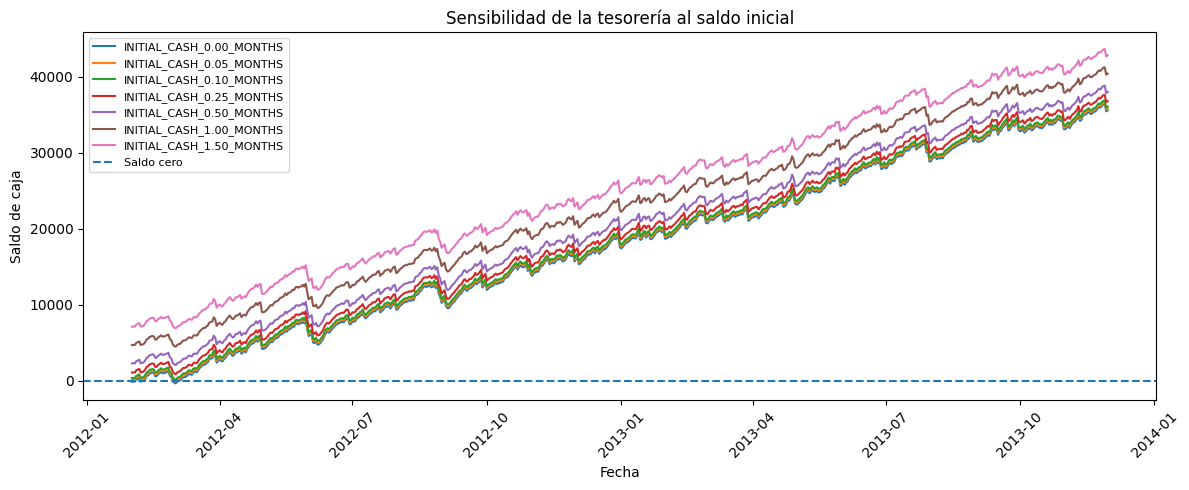

In [22]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

for scenario_name, scenario_df in (
    initial_cash_scenario_daily.items()
):

    ax.plot(
        scenario_df[
            "date"
        ],
        scenario_df[
            "closing_cash_balance"
        ],
        label=scenario_name
    )

ax.axhline(
    0,
    linestyle="--",
    label="Saldo cero"
)

ax.set_title(
    "Sensibilidad de la tesorería al saldo inicial"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend(
    fontsize=8
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Identificar frontera de liquidez

In [23]:
initial_cash_sensitivity[
    "has_liquidity_shortfall"
] = (
    initial_cash_sensitivity[
        "minimum_balance"
    ] < 0
)

initial_cash_sensitivity[
    [
        "scenario",
        "initial_cash",
        "minimum_balance",
        "negative_cash_days",
        "maximum_funding_gap",
        "has_liquidity_shortfall",
    ]
]

,scenario,initial_cash,minimum_balance,negative_cash_days,maximum_funding_gap,has_liquidity_shortfall
0,INITIAL_CASH_0.00_MONTHS,0.000000,-371.650000,11,371.650000,True
1,INITIAL_CASH_0.05_MONTHS,241.226068,-130.423932,2,130.423932,True
2,INITIAL_CASH_0.10_MONTHS,482.452136,110.802136,0,0.000000,False
3,INITIAL_CASH_0.25_MONTHS,1206.130341,834.480341,0,0.000000,False
4,INITIAL_CASH_0.50_MONTHS,2412.260682,2040.610682,0,0.000000,False
5,INITIAL_CASH_1.00_MONTHS,4824.521364,4452.871364,0,0.000000,False
6,INITIAL_CASH_1.50_MONTHS,7236.782045,6865.132045,0,0.000000,False


## Conclusiones del escenario base y sensibilidad al saldo inicial

El análisis confirma que los datasets generados en `08_cashflow_simulation.ipynb` se recuperan correctamente y mantienen todas las conciliaciones realizadas durante la construcción de la simulación.

El motor de escenarios reproduce exactamente la serie diaria original, por lo que puede utilizarse como base para construir escenarios alternativos sin modificar el escenario de referencia.

### Escenario base

El escenario base presenta:

- 141.713,03 unidades monetarias de cobros;
- 106.139,47 unidades monetarias de pagos;
- flujo neto acumulado de +35.573,56;
- saldo inicial de 7.236,78;
- saldo mínimo de 6.865,13;
- saldo final de 42.810,34;
- 0 días con saldo negativo.

Por tanto, el escenario base presenta una posición de liquidez holgada.

### Comportamiento mensual y diario

Solo febrero de 2012 presenta un flujo mensual neto negativo:

`-71,29 unidades monetarias`

Sin embargo, el saldo mínimo de toda la simulación se produce el 2 de marzo de 2012.

Marzo termina posteriormente con un flujo mensual claramente positivo.

Este resultado demuestra que el análisis mensual no es suficiente para identificar todos los momentos de presión financiera.

La secuencia diaria de cobros y pagos puede generar mínimos de liquidez dentro de meses que, considerados de forma agregada, presentan generación positiva de caja.

### Magnitud de las salidas diarias

Los días con mayores salidas no coinciden necesariamente con los días de menor saldo.

La mayor caída diaria de flujo se produce cuando la empresa ya dispone de un saldo acumulado considerable.

Por tanto, el riesgo de liquidez depende de la interacción entre:

- magnitud de los pagos;
- momento en que se producen;
- cobros disponibles;
- saldo acumulado previamente.

Una salida elevada no implica por sí sola una situación de tensión de caja.

### Sensibilidad al saldo inicial

La reducción progresiva del saldo inicial muestra una frontera de liquidez claramente identificable.

Con saldo inicial igual a cero:

- aparecen 11 días con saldo negativo;
- el déficit máximo alcanza aproximadamente 371,65 unidades monetarias.

Con un saldo equivalente a 0,05 meses de salidas medias:

- permanecen 2 días negativos;
- el déficit máximo se reduce hasta aproximadamente 130,42 unidades monetarias.

A partir de 0,10 meses de salidas medias, ninguno de los escenarios analizados presenta saldo negativo.

La frontera matemática exacta para los movimientos observados es aproximadamente:

`371,65 unidades monetarias`

equivalente a:

`0,077 meses de salida media`

o aproximadamente:

`2,3 días de salida media`.

### Interpretación del colchón inicial

El escenario base utiliza:

`7.236,78 unidades monetarias`

equivalentes a 1,5 meses de salidas medias.

Este saldo es aproximadamente 19,5 veces superior al mínimo retrospectivamente necesario para evitar valores negativos en el escenario observado.

Esto confirma que el escenario base fue construido deliberadamente con un colchón de liquidez conservador.

La cifra mínima calculada no debe interpretarse como una recomendación de saldo óptimo.

Se trata únicamente de una medida retrospectiva condicionada por los movimientos concretos incluidos en la simulación.

### Implicación para los siguientes escenarios

La ausencia de problemas de liquidez en el escenario base no impide estudiar riesgo de tesorería.

Al contrario, proporciona una referencia estable frente a la que medir el impacto de perturbaciones posteriores.

Los siguientes escenarios mantendrán inicialmente el mismo saldo de apertura y modificarán el calendario de cobros.

De esta forma será posible aislar el efecto específico que producen los retrasos de clientes sobre la posición de liquidez.

## 6. Escenarios de retraso sistemático en los cobros

El siguiente análisis estudia cómo cambiaría la posición de tesorería si los cobros de clientes se produjeran más tarde que en el escenario base.

Se construirán tres escenarios:

- `DELAY_5_DAYS`: todos los cobros se desplazan 5 días;
- `DELAY_10_DAYS`: todos los cobros se desplazan 10 días;
- `DELAY_15_DAYS`: todos los cobros se desplazan 15 días.

El escenario `BASE` mantendrá las fechas reales de liquidación observadas.

## Variables que permanecerán constantes

Para aislar exclusivamente el efecto del calendario de cobros se mantendrán sin cambios:

- pagos a proveedores;
- obligaciones iniciales;
- nóminas;
- gastos operativos;
- impuestos;
- financiación;
- saldo inicial de caja;
- horizonte temporal.

Por tanto, cualquier diferencia observada entre escenarios podrá atribuirse al desplazamiento de las entradas de caja.

## Interpretación

Estos escenarios representan pruebas de sensibilidad y no predicciones.

No se está afirmando que todas las facturas vayan a retrasarse simultáneamente.

El objetivo es medir cómo responde la liquidez ante un deterioro sistemático en el calendario de cobros.

Los retrasos se expresarán en **días naturales** y no se realizará un ajuste adicional por fines de semana, de forma que cada escenario represente exactamente el desplazamiento temporal definido.

## Cobros posteriores al horizonte

El horizonte principal termina el 30 de noviembre de 2013.

Al retrasar los cobros, algunos movimientos situados cerca del final pueden desplazarse fuera de esta fecha.

Estos importes no se considerarán perdidos.

Se identificarán explícitamente como:

`deferred_receipts_after_horizon`

y representarán cuentas a cobrar que se liquidarían después del período analizado.

Esta separación es necesaria para distinguir entre:

- deterioro temporal de liquidez;
- pérdida económica de un cobro.

En estos escenarios únicamente cambia el momento del cobro, no su importe.

### Identificar cobros modificables

In [24]:
customer_receipt_mask = (
    cash_movements[
        "direction"
    ].eq(
        "CASH_IN"
    )
    &
    cash_movements[
        "movement_type"
    ].eq(
        "CUSTOMER_RECEIPT"
    )
    &
    cash_movements[
        "data_origin"
    ].eq(
        "REAL"
    )
)

customer_receipt_count = (
    customer_receipt_mask.sum()
)

customer_receipt_amount = (
    cash_movements.loc[
        customer_receipt_mask,
        "amount"
    ].sum()
)

customer_receipt_reference = pd.Series({
    "receipt_count": (
        customer_receipt_count
    ),

    "receipt_amount": (
        customer_receipt_amount
    ),

    "first_receipt_date": (
        cash_movements.loc[
            customer_receipt_mask,
            "date"
        ].min()
    ),

    "last_receipt_date": (
        cash_movements.loc[
            customer_receipt_mask,
            "date"
        ].max()
    ),
})

customer_receipt_reference

receipt_count                        2366
receipt_amount                  141713.03
first_receipt_date    2012-02-01 00:00:00
last_receipt_date     2013-11-30 00:00:00
dtype: object

### Validar que movimientos modificaremos

In [25]:
assert (
    customer_receipt_count
    > 0
)

assert np.isclose(
    customer_receipt_amount,
    base_summary[
        "total_cash_in"
    ]
)

assert (
    cash_movements.loc[
        customer_receipt_mask,
        "is_synthetic"
    ]
    .eq(False)
    .all()
)

print(
    "✓ Cobros reales identificados correctamente."
)

✓ Cobros reales identificados correctamente.


### Funcion para desplazar cobros

In [26]:
def create_delayed_receipt_scenario(
    movements,
    delay_days,
):
    """
    Desplaza únicamente los cobros reales de clientes.

    El resto de movimientos mantiene exactamente
    su fecha original.
    """

    scenario_movements = (
        movements
        .copy()
    )

    scenario_movements[
        "original_date"
    ] = (
        scenario_movements[
            "date"
        ]
    )

    receipt_mask = (
        scenario_movements[
            "direction"
        ].eq(
            "CASH_IN"
        )
        &
        scenario_movements[
            "movement_type"
        ].eq(
            "CUSTOMER_RECEIPT"
        )
        &
        scenario_movements[
            "data_origin"
        ].eq(
            "REAL"
        )
    )

    scenario_movements.loc[
        receipt_mask,
        "date"
    ] = (
        scenario_movements.loc[
            receipt_mask,
            "date"
        ]
        +
        pd.to_timedelta(
            delay_days,
            unit="D"
        )
    )

    scenario_movements[
        "date"
    ] = pd.to_datetime(
        scenario_movements[
            "date"
        ]
    ).dt.normalize()

    return scenario_movements

### Validar funcion con retraso cero

In [27]:
zero_delay_movements = (
    create_delayed_receipt_scenario(
        movements=cash_movements,
        delay_days=0,
    )
)

assert (
    zero_delay_movements[
        "date"
    ].reset_index(
        drop=True
    )
    ==
    cash_movements[
        "date"
    ].reset_index(
        drop=True
    )
).all()

assert np.allclose(
    zero_delay_movements[
        "amount"
    ],
    cash_movements[
        "amount"
    ]
)

print(
    "✓ La función reproduce el escenario base "
    "con delay_days = 0."
)

✓ La función reproduce el escenario base con delay_days = 0.


### Configuracion de escenarios

In [28]:
receipt_delay_scenarios = {
    "BASE": 0,
    "DELAY_5_DAYS": 5,
    "DELAY_10_DAYS": 10,
    "DELAY_15_DAYS": 15,
}

receipt_delay_scenarios

{'BASE': 0, 'DELAY_5_DAYS': 5, 'DELAY_10_DAYS': 10, 'DELAY_15_DAYS': 15}

### Ejecutar escenarios

In [29]:
delay_scenario_movements = {}

delay_scenario_daily = {}

delay_scenario_rows = []

for scenario_name, delay_days in (
    receipt_delay_scenarios.items()
):

    scenario_movements = (
        create_delayed_receipt_scenario(
            movements=cash_movements,
            delay_days=delay_days,
        )
    )

    receipt_mask = (
        scenario_movements[
            "direction"
        ].eq(
            "CASH_IN"
        )
        &
        scenario_movements[
            "movement_type"
        ].eq(
            "CUSTOMER_RECEIPT"
        )
        &
        scenario_movements[
            "data_origin"
        ].eq(
            "REAL"
        )
    )

    scenario_receipts = (
        scenario_movements.loc[
            receipt_mask
        ]
        .copy()
    )

    deferred_receipts = (
        scenario_receipts[
            scenario_receipts[
                "date"
            ]
            > simulation_end_date
        ]
        .copy()
    )

    receipts_inside_horizon = (
        scenario_receipts[
            scenario_receipts[
                "date"
            ]
            <= simulation_end_date
        ]
        .copy()
    )

    movements_inside_horizon = (
        scenario_movements[
            scenario_movements[
                "date"
            ].between(
                simulation_start_date,
                simulation_end_date
            )
        ]
        .copy()
    )

    scenario_daily = (
        build_daily_cashflow(
            movements=movements_inside_horizon,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    scenario_metrics = (
        calculate_scenario_metrics(
            daily_df=scenario_daily,
            scenario_name=scenario_name,
            initial_cash=initial_cash_balance,
        )
    )

    scenario_metrics.update({
        "delay_days": (
            delay_days
        ),

        "receipt_count_total": (
            len(
                scenario_receipts
            )
        ),

        "receipt_amount_total": (
            scenario_receipts[
                "amount"
            ].sum()
        ),

        "receipt_count_inside_horizon": (
            len(
                receipts_inside_horizon
            )
        ),

        "receipt_amount_inside_horizon": (
            receipts_inside_horizon[
                "amount"
            ].sum()
        ),

        "deferred_receipt_count": (
            len(
                deferred_receipts
            )
        ),

        "deferred_receipt_amount": (
            deferred_receipts[
                "amount"
            ].sum()
        ),
    })

    delay_scenario_movements[
        scenario_name
    ] = scenario_movements

    delay_scenario_daily[
        scenario_name
    ] = scenario_daily

    delay_scenario_rows.append(
        scenario_metrics
    )

### Tabla de resultados

In [30]:
delay_scenario_summary = (
    pd.DataFrame(
        delay_scenario_rows
    )
    .sort_values(
        "delay_days"
    )
    .reset_index(
        drop=True
    )
)

delay_scenario_summary

,scenario,initial_cash,total_cash_in,total_cash_out,net_cashflow,minimum_balance,minimum_balance_date,final_balance,negative_cash_days,first_negative_date,maximum_funding_gap,delay_days,receipt_count_total,receipt_amount_total,receipt_count_inside_horizon,receipt_amount_inside_horizon,deferred_receipt_count,deferred_receipt_amount
0,BASE,7236.782045,141713.03,106139.47,35573.56,6865.132045,2012-03-02,42810.342045,0,NaT,0.0,0,2366,141713.03,2366,141713.03,0,0.00
1,DELAY_5_DAYS,7236.782045,140720.61,106139.47,34581.14,6081.482045,2012-03-02,41817.922045,0,NaT,0.0,5,2366,141713.03,2350,140720.61,16,992.42
2,DELAY_10_DAYS,7236.782045,139649.18,106139.47,33509.71,5360.922045,2012-02-29,40746.492045,0,NaT,0.0,10,2366,141713.03,2335,139649.18,31,2063.85
3,DELAY_15_DAYS,7236.782045,138899.64,106139.47,32760.17,4365.202045,2012-03-01,39996.952045,0,NaT,0.0,15,2366,141713.03,2323,138899.64,43,2813.39


### Validacion de conservacion de importes

In [31]:
for _, row in (
    delay_scenario_summary.iterrows()
):

    assert np.isclose(
        row[
            "receipt_amount_inside_horizon"
        ]
        +
        row[
            "deferred_receipt_amount"
        ],

        customer_receipt_amount
    )

    assert (
        row[
            "receipt_count_inside_horizon"
        ]
        +
        row[
            "deferred_receipt_count"
        ]
        ==
        customer_receipt_count
    )

print(
    "✓ Todos los cobros están conciliados "
    "en todos los escenarios."
)

✓ Todos los cobros están conciliados en todos los escenarios.


### Validar que las salidad no cambian

In [32]:
base_cash_out = (
    daily_cashflow[
        "cash_out"
    ].sum()
)

for scenario_name, scenario_daily in (
    delay_scenario_daily.items()
):

    assert np.isclose(
        scenario_daily[
            "cash_out"
        ].sum(),
        base_cash_out
    )

print(
    "✓ Las salidas de caja permanecen "
    "constantes en todos los escenarios."
)

✓ Las salidas de caja permanecen constantes en todos los escenarios.


In [33]:
original_movements_by_id = (
    cash_movements
    .set_index("movement_id")
    .sort_index()
)

for scenario_name, delay_days in (
    receipt_delay_scenarios.items()
):

    scenario_by_id = (
        delay_scenario_movements[
            scenario_name
        ]
        .set_index("movement_id")
        .sort_index()
    )

    assert scenario_by_id.index.equals(
        original_movements_by_id.index
    )

    receipt_mask_indexed = (
        original_movements_by_id[
            "direction"
        ].eq("CASH_IN")
        &
        original_movements_by_id[
            "movement_type"
        ].eq("CUSTOMER_RECEIPT")
        &
        original_movements_by_id[
            "data_origin"
        ].eq("REAL")
    )

    # Ningún movimiento distinto de cobros cambia de fecha
    assert (
        scenario_by_id.loc[
            ~receipt_mask_indexed,
            "date"
        ]
        ==
        original_movements_by_id.loc[
            ~receipt_mask_indexed,
            "date"
        ]
    ).all()

    # Cada cobro cambia exactamente los días definidos
    expected_receipt_dates = (
        original_movements_by_id.loc[
            receipt_mask_indexed,
            "date"
        ]
        +
        pd.to_timedelta(
            delay_days,
            unit="D"
        )
    )

    assert (
        scenario_by_id.loc[
            receipt_mask_indexed,
            "date"
        ]
        ==
        expected_receipt_dates
    ).all()

    # Ningún importe cambia
    assert np.allclose(
        scenario_by_id["amount"],
        original_movements_by_id["amount"]
    )

print(
    "✓ Únicamente se modifican las fechas "
    "de los cobros reales."
)

✓ Únicamente se modifican las fechas de los cobros reales.


### Validar escenario BASE

In [34]:
delay_base = (
    delay_scenario_daily[
        "BASE"
    ]
)

assert np.allclose(
    delay_base[
        "cash_in"
    ],
    daily_cashflow[
        "cash_in"
    ]
)

assert np.allclose(
    delay_base[
        "cash_out"
    ],
    daily_cashflow[
        "cash_out"
    ]
)

assert np.allclose(
    delay_base[
        "closing_cash_balance"
    ],
    daily_cashflow[
        "closing_cash_balance"
    ]
)

print(
    "✓ El escenario BASE permanece inalterado."
)

✓ El escenario BASE permanece inalterado.


### Deterioro respecto al escenario base

In [35]:
base_minimum_balance = (
    delay_scenario_summary
    .loc[
        delay_scenario_summary[
            "scenario"
        ] == "BASE",
        "minimum_balance"
    ]
    .iloc[0]
)

base_final_balance = (
    delay_scenario_summary
    .loc[
        delay_scenario_summary[
            "scenario"
        ] == "BASE",
        "final_balance"
    ]
    .iloc[0]
)

delay_scenario_summary[
    "minimum_balance_change_vs_base"
] = (
    delay_scenario_summary[
        "minimum_balance"
    ]
    -
    base_minimum_balance
)

delay_scenario_summary[
    "final_balance_change_vs_base"
] = (
    delay_scenario_summary[
        "final_balance"
    ]
    -
    base_final_balance
)

### Maximo deterioro temporal de caja

In [36]:
base_balance_series = (
    delay_scenario_daily[
        "BASE"
    ][
        "closing_cash_balance"
    ]
    .to_numpy()
)

maximum_balance_deterioration = {}

for scenario_name, scenario_daily in (
    delay_scenario_daily.items()
):

    balance_difference = (
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
        -
        base_balance_series
    )

    maximum_balance_deterioration[
        scenario_name
    ] = (
        balance_difference.min()
    )


delay_scenario_summary[
    "worst_balance_change_vs_base"
] = (
    delay_scenario_summary[
        "scenario"
    ]
    .map(
        maximum_balance_deterioration
    )
)

display(delay_scenario_summary)

delay_scenario_summary[
    "maximum_liquidity_deterioration"
] = (
    -delay_scenario_summary[
        "worst_balance_change_vs_base"
    ]
)

delay_scenario_summary[
    "minimum_balance_reduction_pct"
] = (
    (
        base_minimum_balance
        -
        delay_scenario_summary[
            "minimum_balance"
        ]
    )
    /
    base_minimum_balance
)

delay_impact_summary = (
    delay_scenario_summary[
        [
            "scenario",
            "delay_days",
            "minimum_balance",
            "minimum_balance_reduction_pct",
            "maximum_liquidity_deterioration",
            "negative_cash_days",
            "deferred_receipt_amount",
            "final_balance",
        ]
    ]
    .copy()
)

delay_impact_summary

,scenario,initial_cash,total_cash_in,total_cash_out,net_cashflow,minimum_balance,minimum_balance_date,final_balance,negative_cash_days,first_negative_date,...,delay_days,receipt_count_total,receipt_amount_total,receipt_count_inside_horizon,receipt_amount_inside_horizon,deferred_receipt_count,deferred_receipt_amount,minimum_balance_change_vs_base,final_balance_change_vs_base,worst_balance_change_vs_base
0,BASE,7236.782045,141713.03,106139.47,35573.56,6865.132045,2012-03-02,42810.342045,0,NaT,...,0,2366,141713.03,2366,141713.03,0,0.00,0.00,0.00,0.00
1,DELAY_5_DAYS,7236.782045,140720.61,106139.47,34581.14,6081.482045,2012-03-02,41817.922045,0,NaT,...,5,2366,141713.03,2350,140720.61,16,992.42,-783.65,-992.42,-2085.43
2,DELAY_10_DAYS,7236.782045,139649.18,106139.47,33509.71,5360.922045,2012-02-29,40746.492045,0,NaT,...,10,2366,141713.03,2335,139649.18,31,2063.85,-1504.21,-2063.85,-2938.38
3,DELAY_15_DAYS,7236.782045,138899.64,106139.47,32760.17,4365.202045,2012-03-01,39996.952045,0,NaT,...,15,2366,141713.03,2323,138899.64,43,2813.39,-2499.93,-2813.39,-4253.57


,scenario,delay_days,minimum_balance,minimum_balance_reduction_pct,maximum_liquidity_deterioration,negative_cash_days,deferred_receipt_amount,final_balance
0,BASE,0,6865.132045,0.000000,-0.00,0,0.00,42810.342045
1,DELAY_5_DAYS,5,6081.482045,0.114149,2085.43,0,992.42,41817.922045
2,DELAY_10_DAYS,10,5360.922045,0.219109,2938.38,0,2063.85,40746.492045
3,DELAY_15_DAYS,15,4365.202045,0.364149,4253.57,0,2813.39,39996.952045


### Tabla comparativa simplificada

In [37]:
delay_comparison = (
    delay_scenario_summary[
        [
            "scenario",
            "delay_days",
            "total_cash_in",
            "deferred_receipt_count",
            "deferred_receipt_amount",
            "minimum_balance",
            "minimum_balance_date",
            "minimum_balance_change_vs_base",
            "worst_balance_change_vs_base",
            "negative_cash_days",
            "maximum_funding_gap",
            "final_balance",
            "final_balance_change_vs_base",
        ]
    ]
    .copy()
)

delay_comparison

,scenario,delay_days,total_cash_in,deferred_receipt_count,deferred_receipt_amount,minimum_balance,minimum_balance_date,minimum_balance_change_vs_base,worst_balance_change_vs_base,negative_cash_days,maximum_funding_gap,final_balance,final_balance_change_vs_base
0,BASE,0,141713.03,0,0.00,6865.132045,2012-03-02,0.00,0.00,0,0.0,42810.342045,0.00
1,DELAY_5_DAYS,5,140720.61,16,992.42,6081.482045,2012-03-02,-783.65,-2085.43,0,0.0,41817.922045,-992.42
2,DELAY_10_DAYS,10,139649.18,31,2063.85,5360.922045,2012-02-29,-1504.21,-2938.38,0,0.0,40746.492045,-2063.85
3,DELAY_15_DAYS,15,138899.64,43,2813.39,4365.202045,2012-03-01,-2499.93,-4253.57,0,0.0,39996.952045,-2813.39


### Validacion saldo final

In [38]:
for _, row in (
    delay_scenario_summary.iterrows()
):

    expected_final_difference = (
        -row[
            "deferred_receipt_amount"
        ]
    )

    assert np.isclose(
        row[
            "final_balance_change_vs_base"
        ],
        expected_final_difference,
        atol=0.01
    )

print(
    "✓ La reducción del saldo final coincide "
    "con los cobros diferidos fuera del horizonte."
)

✓ La reducción del saldo final coincide con los cobros diferidos fuera del horizonte.


### Visualizacion de saldos

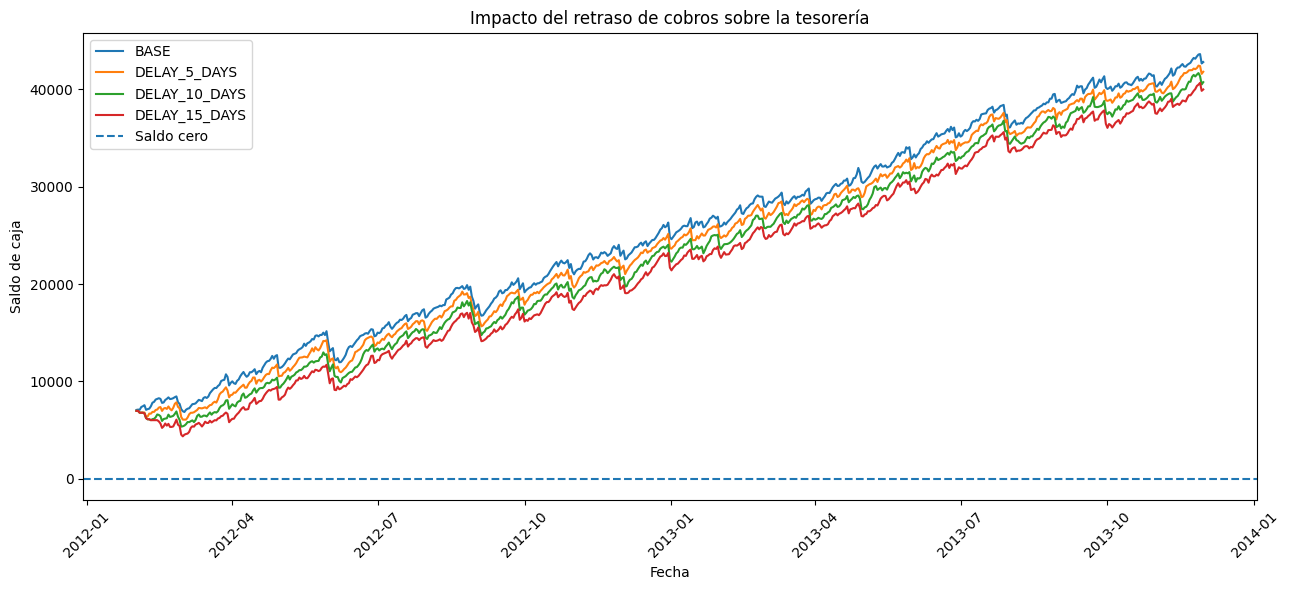

In [39]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

for scenario_name, scenario_daily in (
    delay_scenario_daily.items()
):

    ax.plot(
        scenario_daily[
            "date"
        ],
        scenario_daily[
            "closing_cash_balance"
        ],
        label=scenario_name
    )

ax.axhline(
    0,
    linestyle="--",
    label="Saldo cero"
)

ax.set_title(
    "Impacto del retraso de cobros sobre la tesorería"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Zoom inicio de simulacion

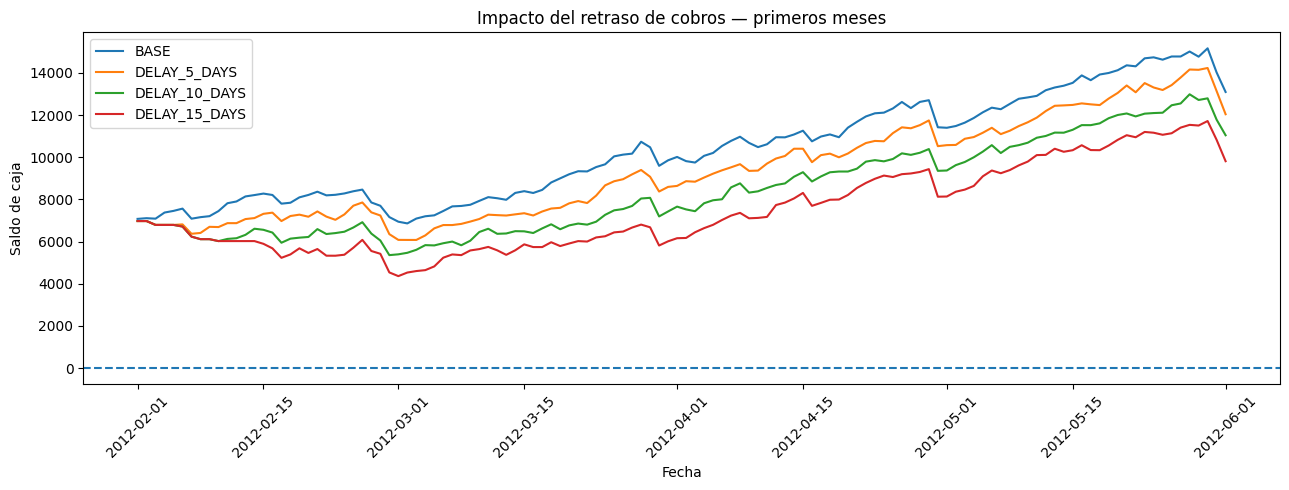

In [40]:
zoom_end_date = (
    simulation_start_date
    + pd.DateOffset(
        months=4
    )
)

fig, ax = plt.subplots(
    figsize=(13, 5)
)

for scenario_name, scenario_daily in (
    delay_scenario_daily.items()
):

    zoom_df = (
        scenario_daily[
            scenario_daily[
                "date"
            ]
            <= zoom_end_date
        ]
    )

    ax.plot(
        zoom_df[
            "date"
        ],
        zoom_df[
            "closing_cash_balance"
        ],
        label=scenario_name
    )

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Impacto del retraso de cobros — primeros meses"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Cobros diferidos fuera del horizone

In [41]:
deferred_receipts_summary = (
    delay_scenario_summary[
        [
            "scenario",
            "delay_days",
            "deferred_receipt_count",
            "deferred_receipt_amount",
        ]
    ]
    .copy()
)

deferred_receipts_summary

,scenario,delay_days,deferred_receipt_count,deferred_receipt_amount
0,BASE,0,0,0.00
1,DELAY_5_DAYS,5,16,992.42
2,DELAY_10_DAYS,10,31,2063.85
3,DELAY_15_DAYS,15,43,2813.39


### Porcentaje de cobros desplazados fuera

In [42]:
deferred_receipts_summary[
    "deferred_receipt_pct"
] = (
    deferred_receipts_summary[
        "deferred_receipt_amount"
    ]
    /
    customer_receipt_amount
)

deferred_receipts_summary

,scenario,delay_days,deferred_receipt_count,deferred_receipt_amount,deferred_receipt_pct
0,BASE,0,0,0.00,0.000000
1,DELAY_5_DAYS,5,16,992.42,0.007003
2,DELAY_10_DAYS,10,31,2063.85,0.014564
3,DELAY_15_DAYS,15,43,2813.39,0.019853


### Interpretación de los escenarios de retraso

Los escenarios anteriores modifican únicamente el momento en que se producen los cobros.

No cambian:

- el importe de las facturas;
- el número de facturas;
- los pagos de la empresa;
- el saldo inicial;
- la estructura de costes.

Por tanto, cualquier deterioro de la posición de caja representa exclusivamente un efecto de **timing**.

La reducción del saldo final dentro del horizonte no debe interpretarse automáticamente como una pérdida económica.

Cuando un cobro se desplaza más allá del 30 de noviembre de 2013, continúa existiendo como derecho de cobro, pero queda fuera de la ventana temporal analizada.

Por este motivo se presentan separadamente:

- saldo final dentro del horizonte;
- número de cobros diferidos;
- importe de cobros diferidos.

El indicador `worst_balance_change_vs_base` permite medir además la mayor reducción temporal de liquidez experimentada en cualquier momento del escenario, incluso cuando posteriormente el saldo se recupera.

Estos escenarios constituyen pruebas de sensibilidad sistemática.

Todavía no incorporan información del modelo predictivo ni seleccionan facturas concretas en función de su riesgo.

## Conclusiones de los escenarios de retraso sistemático

Los escenarios de sensibilidad muestran un deterioro progresivo de la posición de tesorería a medida que aumenta el retraso aplicado a los cobros.

Todas las pruebas mantienen constantes:

- los importes de las facturas;
- los pagos;
- los gastos;
- la estructura de costes;
- el saldo inicial.

La única variable modificada es la fecha de cobro de las facturas de clientes.

Por tanto, las diferencias observadas representan exclusivamente un efecto de calendario o **timing de cobros**.

## Impacto sobre el saldo mínimo

El escenario base presenta un saldo mínimo de:

`6.865,13 unidades monetarias`

Al retrasar todos los cobros, el saldo mínimo pasa aproximadamente a:

- +5 días: `6.081,48`;
- +10 días: `5.360,92`;
- +15 días: `4.365,20`.

Esto representa una reducción respecto al escenario base de aproximadamente:

- +5 días: `11,4 %`;
- +10 días: `21,9 %`;
- +15 días: `36,4 %`.

El deterioro aumenta de forma progresiva a medida que se desplazan las entradas de caja.

## Ausencia de déficit en el escenario base de liquidez

Ninguno de los tres escenarios genera días con saldo negativo.

Incluso cuando todos los cobros se retrasan 15 días, el saldo mínimo permanece positivo:

`4.365,20 unidades monetarias`

Esto confirma que el colchón inicial utilizado en el escenario base es suficientemente amplio para absorber un deterioro sistemático moderado del calendario de cobros.

La ausencia de saldo negativo no implica que el retraso carezca de impacto.

La liquidez disponible disminuye de forma considerable, aunque no llegue a agotarse.

## Máximo deterioro temporal

El impacto de los retrasos no debe evaluarse únicamente mediante el saldo final.

La mayor diferencia temporal de caja respecto al escenario base alcanza aproximadamente:

- +5 días: `2.085,43`;
- +10 días: `2.938,38`;
- +15 días: `4.253,57`.

En el escenario de +15 días, la empresa llega por tanto a disponer temporalmente de más de 4.200 unidades monetarias menos que en el escenario base.

Este deterioro es superior a la diferencia observada al final del horizonte.

Esto ocurre porque durante determinados períodos se acumulan simultáneamente varios cobros retrasados que posteriormente terminan entrando en caja.

Por tanto, el análisis del riesgo de liquidez requiere estudiar toda la trayectoria temporal del saldo y no únicamente su valor final.

## Cobros desplazados fuera del horizonte

Al retrasar los cobros situados cerca del final del período, algunos movimientos quedan después del 30 de noviembre de 2013.

Los importes desplazados son:

- +5 días: 16 cobros por `992,42`;
- +10 días: 31 cobros por `2.063,85`;
- +15 días: 43 cobros por `2.813,39`.

Estos importes representan aproximadamente:

- `0,70 %`;
- `1,46 %`;
- `1,99 %`;

respectivamente, del total de cobros reales del horizonte.

Estos cobros no se consideran perdidos.

Continúan existiendo como derechos de cobro, pero su entrada de caja se produciría después del final de la ventana analizada.

Por este motivo, la reducción del saldo final de cada escenario coincide exactamente con el importe de cobros diferidos fuera del horizonte.

## Saldo final

El saldo final disminuye progresivamente:

- BASE: `42.810,34`;
- +5 días: `41.817,92`;
- +10 días: `40.746,49`;
- +15 días: `39.996,95`.

Sin embargo, esta diferencia final está influida por el límite temporal de la simulación y no representa una pérdida económica.

El indicador más informativo para estudiar tensión de tesorería es el comportamiento del saldo durante todo el horizonte.

## Interpretación empresarial

Los resultados muestran que una empresa puede mantener un flujo acumulado positivo y continuar siendo solvente, pero experimentar una reducción relevante de su liquidez disponible cuando se deteriora el calendario de cobros.

El riesgo de retraso afecta por tanto a la tesorería incluso cuando las facturas terminan siendo cobradas.

El problema económico no es necesariamente perder el ingreso, sino disponer del efectivo más tarde de lo previsto.

Esta diferencia temporal puede afectar a la capacidad para afrontar:

- proveedores;
- nóminas;
- impuestos;
- financiación;
- otros compromisos operativos.

## Limitación del escenario

Los escenarios de +5, +10 y +15 días retrasan todas las facturas de forma uniforme.

Se trata deliberadamente de pruebas de sensibilidad simples y no de predicciones realistas del comportamiento individual de los clientes.

En la práctica, no todas las facturas presentan el mismo riesgo ni sufrirían el mismo retraso.

El siguiente paso será abandonar este supuesto uniforme y construir escenarios selectivos en los que solo determinados cobros sean modificados.

Esto permitirá posteriormente conectar la simulación de tesorería con el riesgo predictivo estimado para cada factura.

## 7. Escenarios selectivos de retraso

Los escenarios anteriores aplicaban el mismo retraso a todos los cobros de clientes.

Este supuesto es útil como prueba de sensibilidad, pero no representa el comportamiento habitual de una cartera real, ya que no todas las facturas presentan el mismo nivel de exposición ni sufrirían simultáneamente un retraso.

El siguiente análisis introduce escenarios **selectivos**, en los que únicamente se modificará un subconjunto de cobros.

## Objetivo

Se estudiarán dos criterios de selección:

### Selección aleatoria

Se retrasará una muestra reproducible del 25 % de los cobros.

Este escenario funcionará como benchmark neutral.

### Selección por exposición

Se retrasarán las facturas de mayor importe.

Se analizarán tres niveles:

- 10 % de los cobros de mayor importe;
- 25 % de los cobros de mayor importe;
- 50 % de los cobros de mayor importe.

En todos estos escenarios el retraso será de:

`+10 días`

De esta forma se mantiene constante la intensidad temporal del shock y se modifica únicamente el número y tipo de facturas afectadas.

## Interpretación

La selección por importe no representa una predicción de retraso.

Debe interpretarse como un escenario de **exposición financiera**:

> ¿qué ocurriría si determinadas entradas de caja especialmente relevantes se retrasasen?

Por su parte, la selección aleatoria proporciona una referencia contra la que posteriormente podrá compararse la selección basada en el modelo predictivo.

Esta estructura permitirá distinguir tres conceptos:

- selección aleatoria;
- exposición económica;
- riesgo predictivo.

El modelo de riesgo se incorporará posteriormente manteniendo esta misma metodología de comparación.

### Universo de cobros

In [43]:
receipt_universe = (
    cash_movements.loc[
        customer_receipt_mask,
        [
            "movement_id",
            "date",
            "amount",
            "reference_id",
            "counterparty_id",
        ]
    ]
    .copy()
    .rename(
        columns={
            "reference_id": "invoice_id",
            "counterparty_id": "customer_id",
        }
    )
    .sort_values(
        [
            "date",
            "movement_id",
        ]
    )
    .reset_index(
        drop=True
    )
)

receipt_universe.head()

,movement_id,date,amount,invoice_id,customer_id
0,COL_000817,2012-02-01,28.84,3314980148,6077-FDQRK
1,COL_001945,2012-02-01,74.01,7867318195,5148-SYKLB
2,COL_001430,2012-02-02,32.78,5831823402,2687-XWAMA
3,COL_000545,2012-02-03,47.07,2195380883,6627-ELFBK
4,COL_001299,2012-02-03,47.75,5215762025,7372-CESLR


### Validar universo

In [44]:
receipt_universe_checks = pd.Series({
    "receipt_count": (
        len(receipt_universe)
    ),

    "unique_movement_ids": (
        receipt_universe[
            "movement_id"
        ].nunique()
    ),

    "unique_invoice_ids": (
        receipt_universe[
            "invoice_id"
        ].nunique()
    ),

    "total_amount": (
        receipt_universe[
            "amount"
        ].sum()
    ),

    "average_amount": (
        receipt_universe[
            "amount"
        ].mean()
    ),

    "median_amount": (
        receipt_universe[
            "amount"
        ].median()
    ),
})

display(receipt_universe_checks)

assert (
    len(receipt_universe)
    ==
    customer_receipt_count
)

assert receipt_universe[
    "movement_id"
].is_unique

assert receipt_universe[
    "invoice_id"
].is_unique

assert np.isclose(
    receipt_universe[
        "amount"
    ].sum(),
    customer_receipt_amount
)

print(
    "✓ Universo de cobros validado."
)

receipt_count            2366.000000
unique_movement_ids      2366.000000
unique_invoice_ids       2366.000000
total_amount           141713.030000
average_amount             59.895617
median_amount              60.615000
dtype: float64

✓ Universo de cobros validado.


### Funcion para seleccionar los cobros de mayor importe

In [45]:
def select_top_receipts_by_amount(
    receipts,
    share,
):
    """
    Selecciona una proporción de cobros
    ordenados de mayor a menor importe.
    """

    if not (
        0 < share <= 1
    ):
        raise ValueError(
            "share debe estar entre 0 y 1."
        )

    selected_count = max(
        1,
        int(
            np.ceil(
                len(receipts)
                * share
            )
        )
    )

    selected = (
        receipts
        .sort_values(
            [
                "amount",
                "movement_id",
            ],
            ascending=[
                False,
                True,
            ]
        )
        .head(
            selected_count
        )
        .copy()
    )

    return set(
        selected[
            "movement_id"
        ]
    )

### Construir subconjuntos por exposicion

In [46]:
high_value_10_ids = (
    select_top_receipts_by_amount(
        receipts=receipt_universe,
        share=0.10,
    )
)

high_value_25_ids = (
    select_top_receipts_by_amount(
        receipts=receipt_universe,
        share=0.25,
    )
)

high_value_50_ids = (
    select_top_receipts_by_amount(
        receipts=receipt_universe,
        share=0.50,
    )
)

### Benchmark aleatorio reproducible

In [47]:
selective_rng = np.random.default_rng(
    int(
        simulation_metadata[
            "random_seed"
        ]
    )
    + 2000
)

random_25_count = (
    len(
        high_value_25_ids
    )
)

random_25_ids = set(
    selective_rng.choice(
        receipt_universe[
            "movement_id"
        ].to_numpy(),
        size=random_25_count,
        replace=False,
    )
)

### Validar tamaños de los subconjuntos

In [48]:
selection_size_summary = pd.Series({
    "total_receipts": (
        len(receipt_universe)
    ),

    "high_value_10_count": (
        len(high_value_10_ids)
    ),

    "high_value_25_count": (
        len(high_value_25_ids)
    ),

    "random_25_count": (
        len(random_25_ids)
    ),

    "high_value_50_count": (
        len(high_value_50_ids)
    ),
})

display(selection_size_summary)

assert (
    len(random_25_ids)
    ==
    len(high_value_25_ids)
)

assert high_value_10_ids.issubset(
    high_value_25_ids
)

assert high_value_25_ids.issubset(
    high_value_50_ids
)

print(
    "✓ Subconjuntos selectivos validados."
)

total_receipts         2366
high_value_10_count     237
high_value_25_count     592
random_25_count         592
high_value_50_count    1183
dtype: int64

✓ Subconjuntos selectivos validados.


### Resumen economico de las selecciones

In [49]:
def summarize_receipt_selection(
    receipts,
    selected_ids,
    selection_name,
):
    selected = (
        receipts[
            receipts[
                "movement_id"
            ].isin(
                selected_ids
            )
        ]
    )

    return {
        "selection": (
            selection_name
        ),

        "selected_count": (
            len(selected)
        ),

        "selected_count_pct": (
            len(selected)
            /
            len(receipts)
        ),

        "selected_amount": (
            selected[
                "amount"
            ].sum()
        ),

        "selected_amount_pct": (
            selected[
                "amount"
            ].sum()
            /
            receipts[
                "amount"
            ].sum()
        ),

        "average_selected_amount": (
            selected[
                "amount"
            ].mean()
        ),
    }

### Tabla de exposicion

In [50]:
selection_exposure_summary = pd.DataFrame([
    summarize_receipt_selection(
        receipt_universe,
        high_value_10_ids,
        "HIGH_VALUE_10",
    ),

    summarize_receipt_selection(
        receipt_universe,
        high_value_25_ids,
        "HIGH_VALUE_25",
    ),

    summarize_receipt_selection(
        receipt_universe,
        random_25_ids,
        "RANDOM_25",
    ),

    summarize_receipt_selection(
        receipt_universe,
        high_value_50_ids,
        "HIGH_VALUE_50",
    ),
])

selection_exposure_summary

,selection,selected_count,selected_count_pct,selected_amount,selected_amount_pct,average_selected_amount
0,HIGH_VALUE_10,237,0.100169,22374.75,0.157888,94.408228
1,HIGH_VALUE_25,592,0.250211,50536.75,0.356613,85.366132
2,RANDOM_25,592,0.250211,34535.18,0.243698,58.336453
3,HIGH_VALUE_50,1183,0.500000,90026.00,0.635270,76.099746


### Número de facturas frente a exposición monetaria

El porcentaje de facturas afectadas y el porcentaje de importe afectado no tienen por qué coincidir.

Por ejemplo, seleccionar el 25 % de las facturas de mayor importe puede representar considerablemente más del 25 % del volumen monetario de cobros.

Por este motivo, cada escenario se describirá mediante dos dimensiones:

- porcentaje de facturas afectadas;
- porcentaje del importe total afectado.

Esta distinción será también importante posteriormente cuando se incorporen probabilidades de riesgo.

Un escenario que identifique correctamente pocas facturas de importe elevado puede tener un impacto financiero mayor que otro que afecte a un número superior de facturas pequeñas.

### Funcion de retraso selectivo

In [51]:
def create_selective_delay_scenario(
    movements,
    selected_movement_ids,
    delay_days,
):
    """
    Retrasa únicamente los cobros de clientes
    cuyos movement_id han sido seleccionados.
    """

    scenario_movements = (
        movements
        .copy()
    )

    scenario_movements[
        "original_date"
    ] = (
        scenario_movements[
            "date"
        ]
    )

    receipt_mask = (
        scenario_movements[
            "direction"
        ].eq(
            "CASH_IN"
        )
        &
        scenario_movements[
            "movement_type"
        ].eq(
            "CUSTOMER_RECEIPT"
        )
        &
        scenario_movements[
            "data_origin"
        ].eq(
            "REAL"
        )
    )

    selected_mask = (
        receipt_mask
        &
        scenario_movements[
            "movement_id"
        ].isin(
            selected_movement_ids
        )
    )

    scenario_movements[
        "delayed_in_scenario"
    ] = selected_mask

    scenario_movements[
        "scenario_delay_days"
    ] = np.where(
        selected_mask,
        delay_days,
        0,
    )

    scenario_movements.loc[
        selected_mask,
        "date"
    ] = (
        scenario_movements.loc[
            selected_mask,
            "date"
        ]
        +
        pd.to_timedelta(
            delay_days,
            unit="D"
        )
    )

    scenario_movements[
        "date"
    ] = pd.to_datetime(
        scenario_movements[
            "date"
        ]
    ).dt.normalize()

    return scenario_movements

### Validar funcion selectiva

In [52]:
selective_zero_test = (
    create_selective_delay_scenario(
        movements=cash_movements,
        selected_movement_ids=set(),
        delay_days=10,
    )
)

assert (
    selective_zero_test[
        "date"
    ].reset_index(
        drop=True
    )
    ==
    cash_movements[
        "date"
    ].reset_index(
        drop=True
    )
).all()

assert (
    selective_zero_test[
        "delayed_in_scenario"
    ].sum()
    == 0
)

print(
    "✓ Función selectiva validada "
    "sin movimientos seleccionados."
)

✓ Función selectiva validada sin movimientos seleccionados.


### Definir escenarios selectivos

In [53]:
SELECTIVE_DELAY_DAYS = 10

selective_scenario_specs = {
    "BASE": {
        "selection_rule": "NONE",
        "selected_ids": set(),
        "delay_days": 0,
    },

    "RANDOM_25_DELAY_10": {
        "selection_rule": "RANDOM_25",
        "selected_ids": random_25_ids,
        "delay_days": SELECTIVE_DELAY_DAYS,
    },

    "HIGH_VALUE_10_DELAY_10": {
        "selection_rule": "HIGH_VALUE_10",
        "selected_ids": high_value_10_ids,
        "delay_days": SELECTIVE_DELAY_DAYS,
    },

    "HIGH_VALUE_25_DELAY_10": {
        "selection_rule": "HIGH_VALUE_25",
        "selected_ids": high_value_25_ids,
        "delay_days": SELECTIVE_DELAY_DAYS,
    },

    "HIGH_VALUE_50_DELAY_10": {
        "selection_rule": "HIGH_VALUE_50",
        "selected_ids": high_value_50_ids,
        "delay_days": SELECTIVE_DELAY_DAYS,
    },
}

### Ejecutar escenarios

In [54]:
selective_scenario_movements = {}

selective_scenario_daily = {}

selective_scenario_rows = []

for scenario_name, spec in (
    selective_scenario_specs.items()
):

    selected_ids = (
        spec[
            "selected_ids"
        ]
    )

    delay_days = (
        spec[
            "delay_days"
        ]
    )

    scenario_movements = (
        create_selective_delay_scenario(
            movements=cash_movements,
            selected_movement_ids=selected_ids,
            delay_days=delay_days,
        )
    )

    scenario_receipts = (
        scenario_movements[
            scenario_movements[
            "direction"
            ].eq(
                "CASH_IN"
            )
            &
            scenario_movements[
                "movement_type"
        ].eq(
            "CUSTOMER_RECEIPT"
        )
        &
        scenario_movements[
            "data_origin"
        ].eq(
            "REAL"
        )
    ]
    .copy()
)

    deferred_receipts = (
        scenario_receipts[
            scenario_receipts[
                "date"
            ]
            > simulation_end_date
        ]
        .copy()
    )

    movements_inside_horizon = (
        scenario_movements[
            scenario_movements[
                "date"
            ].between(
                simulation_start_date,
                simulation_end_date
            )
        ]
        .copy()
    )

    scenario_daily = (
        build_daily_cashflow(
            movements=movements_inside_horizon,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    scenario_metrics = (
        calculate_scenario_metrics(
            daily_df=scenario_daily,
            scenario_name=scenario_name,
            initial_cash=initial_cash_balance,
        )
    )

    selected_receipts = (
        receipt_universe[
            receipt_universe[
                "movement_id"
            ].isin(
                selected_ids
            )
        ]
    )

    scenario_metrics.update({
        "selection_rule": (
            spec[
                "selection_rule"
            ]
        ),

        "delay_days": (
            delay_days
        ),

        "selected_receipt_count": (
            len(
                selected_receipts
            )
        ),

        "selected_receipt_pct": (
            len(
                selected_receipts
            )
            /
            len(
                receipt_universe
            )
        ),

        "selected_receipt_amount": (
            selected_receipts[
                "amount"
            ].sum()
        ),

        "selected_amount_pct": (
            selected_receipts[
                "amount"
            ].sum()
            /
            customer_receipt_amount
        ),

        "deferred_receipt_count": (
            len(
                deferred_receipts
            )
        ),

        "deferred_receipt_amount": (
            deferred_receipts[
                "amount"
            ].sum()
        ),
    })

    selective_scenario_movements[
        scenario_name
    ] = scenario_movements

    selective_scenario_daily[
        scenario_name
    ] = scenario_daily

    selective_scenario_rows.append(
        scenario_metrics
    )

### Tabla de resultados

In [55]:
selective_scenario_summary = (
    pd.DataFrame(
        selective_scenario_rows
    )
)

selective_scenario_summary

,scenario,initial_cash,total_cash_in,total_cash_out,net_cashflow,minimum_balance,minimum_balance_date,final_balance,negative_cash_days,first_negative_date,maximum_funding_gap,selection_rule,delay_days,selected_receipt_count,selected_receipt_pct,selected_receipt_amount,selected_amount_pct,deferred_receipt_count,deferred_receipt_amount
0,BASE,7236.782045,141713.03,106139.47,35573.56,6865.132045,2012-03-02,42810.342045,0,NaT,0.0,NONE,0,0,0.000000,0.00,0.000000,0,0.00
1,RANDOM_25_DELAY_10,7236.782045,140791.35,106139.47,34651.88,6665.012045,2012-03-02,41888.662045,0,NaT,0.0,RANDOM_25,10,592,0.250211,34535.18,0.243698,13,921.68
2,HIGH_VALUE_10_DELAY_10,7236.782045,141070.90,106139.47,34931.43,6498.202045,2012-03-02,42168.212045,0,NaT,0.0,HIGH_VALUE_10,10,237,0.100169,22374.75,0.157888,7,642.13
3,HIGH_VALUE_25_DELAY_10,7236.782045,140585.28,106139.47,34445.81,6267.562045,2012-03-02,41682.592045,0,NaT,0.0,HIGH_VALUE_25,10,592,0.250211,50536.75,0.356613,13,1127.75
4,HIGH_VALUE_50_DELAY_10,7236.782045,140309.91,106139.47,34170.44,5786.292045,2012-03-02,41407.222045,0,NaT,0.0,HIGH_VALUE_50,10,1183,0.500000,90026.00,0.635270,17,1403.12


### Validar escenarios selectivos

In [56]:
base_movements_indexed = (
    cash_movements
    .set_index(
        "movement_id"
    )
    .sort_index()
)

for scenario_name, spec in (
    selective_scenario_specs.items()
):

    scenario_indexed = (
        selective_scenario_movements[
            scenario_name
        ]
        .set_index(
            "movement_id"
        )
        .sort_index()
    )

    selected_ids = (
        spec[
            "selected_ids"
        ]
    )

    delay_days = (
        spec[
            "delay_days"
        ]
    )

    selected_mask = (
        base_movements_indexed
        .index
        .isin(
            selected_ids
        )
    )

    # Todos los movimientos siguen presentes
    assert scenario_indexed.index.equals(
        base_movements_indexed.index
    )

    # Ningún importe cambia
    assert np.allclose(
        scenario_indexed[
            "amount"
        ],
        base_movements_indexed[
            "amount"
        ]
    )

    # Movimientos no seleccionados:
    # fecha exactamente igual
    assert (
        scenario_indexed.loc[
            ~selected_mask,
            "date"
        ]
        ==
        base_movements_indexed.loc[
            ~selected_mask,
            "date"
        ]
    ).all()

    if len(
        selected_ids
    ) > 0:

        expected_dates = (
            base_movements_indexed.loc[
                selected_mask,
                "date"
            ]
            +
            pd.to_timedelta(
                delay_days,
                unit="D"
            )
        )

        assert (
            scenario_indexed.loc[
                selected_mask,
                "date"
            ]
            ==
            expected_dates
        ).all()

print(
    "✓ Escenarios selectivos validados."
)

✓ Escenarios selectivos validados.


### Validar que las salidas siguen constantes

In [57]:
for scenario_name, scenario_daily in (
    selective_scenario_daily.items()
):

    assert np.isclose(
        scenario_daily[
            "cash_out"
        ].sum(),
        base_cash_out
    )

print(
    "✓ Las salidas permanecen constantes."
)

✓ Las salidas permanecen constantes.


### Conciliar cobros

In [58]:
for scenario_name, scenario_movements in (
    selective_scenario_movements.items()
):

    scenario_receipts = (
        scenario_movements[
            scenario_movements[
                "direction"
            ].eq(
                "CASH_IN"
            )
            &
            scenario_movements[
                "movement_type"
            ].eq(
                "CUSTOMER_RECEIPT"
            )
            &
            scenario_movements[
                "data_origin"
            ].eq(
                "REAL"
            )
        ]
    )

    assert np.isclose(
        scenario_receipts[
            "amount"
        ].sum(),
        customer_receipt_amount
    )

    assert (
        len(
            scenario_receipts
        )
        ==
        customer_receipt_count
    )

print(
    "✓ Todos los cobros reales se conservan "
    "en todos los escenarios."
)

✓ Todos los cobros reales se conservan en todos los escenarios.


### Calcular deterioro frente a BASE

In [59]:
selective_base_daily = (
    selective_scenario_daily[
        "BASE"
    ]
)

selective_base_balance = (
    selective_base_daily[
        "closing_cash_balance"
    ]
    .to_numpy()
)

maximum_deterioration_values = {}

maximum_deterioration_dates = {}

for scenario_name, scenario_daily in (
    selective_scenario_daily.items()
):

    deterioration = (
        selective_base_balance
        -
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    max_position = int(
        np.argmax(
            deterioration
        )
    )

    maximum_deterioration_values[
        scenario_name
    ] = float(
        deterioration[
            max_position
        ]
    )

    maximum_deterioration_dates[
        scenario_name
    ] = (
        scenario_daily.iloc[
            max_position
        ][
            "date"
        ]
    )

### Añadir metricas comparativas

In [60]:
selective_base_minimum = (
    selective_scenario_summary.loc[
        selective_scenario_summary[
            "scenario"
        ].eq(
            "BASE"
        ),
        "minimum_balance"
    ]
    .iloc[0]
)

selective_base_final = (
    selective_scenario_summary.loc[
        selective_scenario_summary[
            "scenario"
        ].eq(
            "BASE"
        ),
        "final_balance"
    ]
    .iloc[0]
)

selective_scenario_summary[
    "minimum_balance_change_vs_base"
] = (
    selective_scenario_summary[
        "minimum_balance"
    ]
    -
    selective_base_minimum
)

selective_scenario_summary[
    "minimum_balance_reduction_pct"
] = (
    (
        selective_base_minimum
        -
        selective_scenario_summary[
            "minimum_balance"
        ]
    )
    /
    selective_base_minimum
)

selective_scenario_summary[
    "maximum_liquidity_deterioration"
] = (
    selective_scenario_summary[
        "scenario"
    ]
    .map(
        maximum_deterioration_values
    )
)

selective_scenario_summary[
    "maximum_deterioration_date"
] = (
    selective_scenario_summary[
        "scenario"
    ]
    .map(
        maximum_deterioration_dates
    )
)

selective_scenario_summary[
    "final_balance_change_vs_base"
] = (
    selective_scenario_summary[
        "final_balance"
    ]
    -
    selective_base_final
)

In [61]:
selective_scenario_summary.loc[
    selective_scenario_summary[
        "scenario"
    ].eq(
        "BASE"
    ),
    "maximum_deterioration_date"
] = pd.NaT

### Tabla final del bloque

In [62]:
selective_comparison = (
    selective_scenario_summary[
        [
            "scenario",
            "selection_rule",
            "delay_days",
            "selected_receipt_count",
            "selected_receipt_pct",
            "selected_receipt_amount",
            "selected_amount_pct",
            "minimum_balance",
            "minimum_balance_reduction_pct",
            "maximum_liquidity_deterioration",
            "maximum_deterioration_date",
            "negative_cash_days",
            "maximum_funding_gap",
            "deferred_receipt_count",
            "deferred_receipt_amount",
            "final_balance",
        ]
    ]
    .copy()
)

selective_comparison

,scenario,selection_rule,delay_days,selected_receipt_count,selected_receipt_pct,selected_receipt_amount,selected_amount_pct,minimum_balance,minimum_balance_reduction_pct,maximum_liquidity_deterioration,maximum_deterioration_date,negative_cash_days,maximum_funding_gap,deferred_receipt_count,deferred_receipt_amount,final_balance
0,BASE,NONE,0,0,0.000000,0.00,0.000000,6865.132045,0.000000,0.00,NaT,0,0.0,0,0.00,42810.342045
1,RANDOM_25_DELAY_10,RANDOM_25,10,592,0.250211,34535.18,0.243698,6665.012045,0.029150,1012.65,2012-09-16,0,0.0,13,921.68,41888.662045
2,HIGH_VALUE_10_DELAY_10,HIGH_VALUE_10,10,237,0.100169,22374.75,0.157888,6498.202045,0.053448,746.43,2012-11-08,0,0.0,7,642.13,42168.212045
3,HIGH_VALUE_25_DELAY_10,HIGH_VALUE_25,10,592,0.250211,50536.75,0.356613,6267.562045,0.087044,1430.16,2013-05-06,0,0.0,13,1127.75,41682.592045
4,HIGH_VALUE_50_DELAY_10,HIGH_VALUE_50,10,1183,0.500000,90026.00,0.635270,5786.292045,0.157148,2168.92,2013-09-04,0,0.0,17,1403.12,41407.222045


### Validar saldo final y cobros diferidos

In [63]:
for _, row in (
    selective_scenario_summary.iterrows()
):

    expected_final_change = (
        -row[
            "deferred_receipt_amount"
        ]
    )

    assert np.isclose(
        row[
            "final_balance_change_vs_base"
        ],
        expected_final_change,
        atol=0.01
    )

print(
    "✓ El cambio de saldo final se explica "
    "por los cobros diferidos fuera del horizonte."
)

✓ El cambio de saldo final se explica por los cobros diferidos fuera del horizonte.


### Comparacion visual de escenarios selectivos

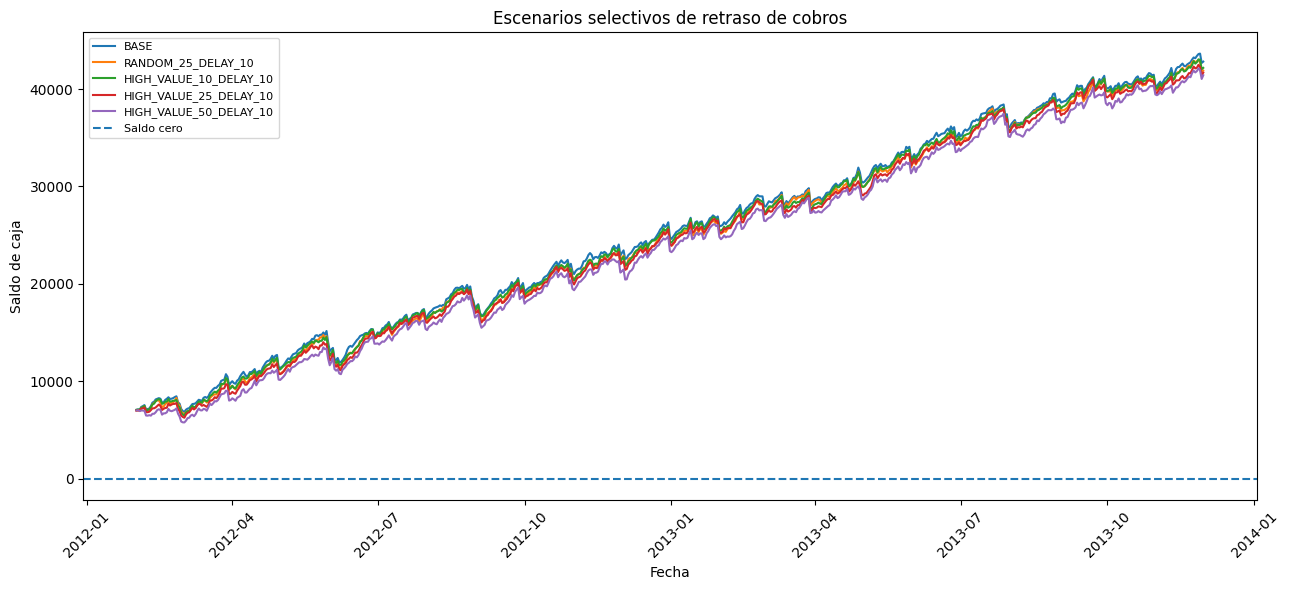

In [64]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

for scenario_name, scenario_daily in (
    selective_scenario_daily.items()
):

    ax.plot(
        scenario_daily[
            "date"
        ],
        scenario_daily[
            "closing_cash_balance"
        ],
        label=scenario_name
    )

ax.axhline(
    0,
    linestyle="--",
    label="Saldo cero"
)

ax.set_title(
    "Escenarios selectivos de retraso de cobros"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend(
    fontsize=8
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Comparacion de saldo minimo

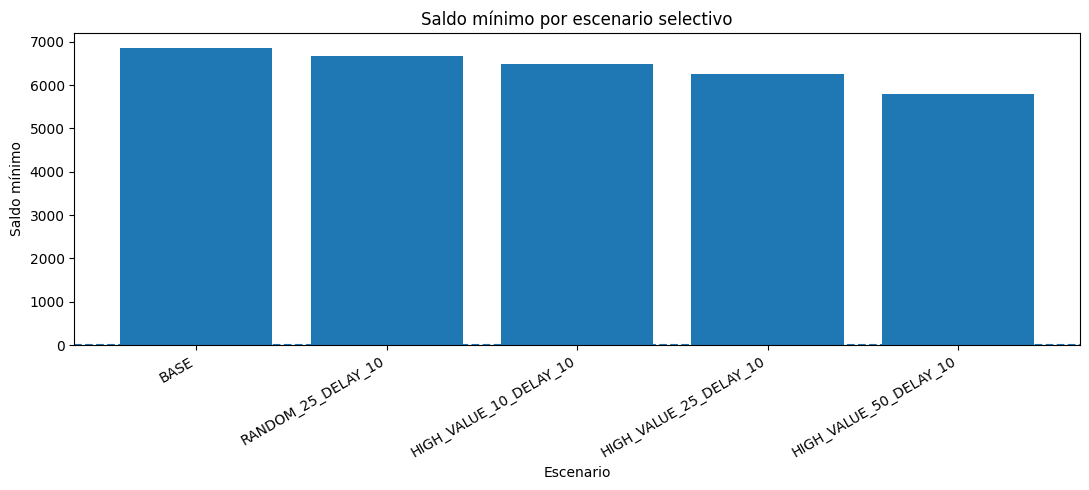

In [65]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    selective_comparison[
        "scenario"
    ],
    selective_comparison[
        "minimum_balance"
    ]
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Saldo mínimo por escenario selectivo"
)

ax.set_xlabel(
    "Escenario"
)

ax.set_ylabel(
    "Saldo mínimo"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

### RANDOM 25 VS HIGH VALUE 25

In [66]:
random_vs_high_value_25 = (
    selective_comparison[
        selective_comparison[
            "scenario"
        ].isin(
            [
                "RANDOM_25_DELAY_10",
                "HIGH_VALUE_25_DELAY_10",
            ]
        )
    ]
    [
        [
            "scenario",
            "selected_receipt_count",
            "selected_receipt_pct",
            "selected_receipt_amount",
            "selected_amount_pct",
            "minimum_balance",
            "maximum_liquidity_deterioration",
            "negative_cash_days",
            "deferred_receipt_amount",
        ]
    ]
)

random_vs_high_value_25

,scenario,selected_receipt_count,selected_receipt_pct,selected_receipt_amount,selected_amount_pct,minimum_balance,maximum_liquidity_deterioration,negative_cash_days,deferred_receipt_amount
1,RANDOM_25_DELAY_10,592,0.250211,34535.18,0.243698,6665.012045,1012.65,0,921.68
3,HIGH_VALUE_25_DELAY_10,592,0.250211,50536.75,0.356613,6267.562045,1430.16,0,1127.75


### Comparacion con retraso uniforme de +10 dias

In [67]:
uniform_delay_10_row = (
    delay_scenario_summary[
        delay_scenario_summary[
            "scenario"
        ].eq(
            "DELAY_10_DAYS"
        )
    ]
    .iloc[0]
)

stress_scope_comparison = pd.DataFrame([
    {
        "scenario": "BASE",
        "affected_receipt_pct": 0.0,
        "affected_amount_pct": 0.0,
        "minimum_balance": (
            selective_base_minimum
        ),
        "maximum_liquidity_deterioration": 0.0,
    },

    {
        "scenario": "RANDOM_25_DELAY_10",
        "affected_receipt_pct": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "RANDOM_25_DELAY_10"
                ),
                "selected_receipt_pct"
            ].iloc[0]
        ),
        "affected_amount_pct": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "RANDOM_25_DELAY_10"
                ),
                "selected_amount_pct"
            ].iloc[0]
        ),
        "minimum_balance": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "RANDOM_25_DELAY_10"
                ),
                "minimum_balance"
            ].iloc[0]
        ),
        "maximum_liquidity_deterioration": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "RANDOM_25_DELAY_10"
                ),
                "maximum_liquidity_deterioration"
            ].iloc[0]
        ),
    },

    {
        "scenario": "HIGH_VALUE_25_DELAY_10",
        "affected_receipt_pct": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "HIGH_VALUE_25_DELAY_10"
                ),
                "selected_receipt_pct"
            ].iloc[0]
        ),
        "affected_amount_pct": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "HIGH_VALUE_25_DELAY_10"
                ),
                "selected_amount_pct"
            ].iloc[0]
        ),
        "minimum_balance": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "HIGH_VALUE_25_DELAY_10"
                ),
                "minimum_balance"
            ].iloc[0]
        ),
        "maximum_liquidity_deterioration": (
            selective_scenario_summary.loc[
                selective_scenario_summary[
                    "scenario"
                ].eq(
                    "HIGH_VALUE_25_DELAY_10"
                ),
                "maximum_liquidity_deterioration"
            ].iloc[0]
        ),
    },

    {
        "scenario": "ALL_RECEIPTS_DELAY_10",
        "affected_receipt_pct": 1.0,
        "affected_amount_pct": 1.0,
        "minimum_balance": (
            uniform_delay_10_row[
                "minimum_balance"
            ]
        ),
        "maximum_liquidity_deterioration": (
            uniform_delay_10_row[
                "maximum_liquidity_deterioration"
            ]
        ),
    },
])

stress_scope_comparison

,scenario,affected_receipt_pct,affected_amount_pct,minimum_balance,maximum_liquidity_deterioration
0,BASE,0.000000,0.000000,6865.132045,0.00
1,RANDOM_25_DELAY_10,0.250211,0.243698,6665.012045,1012.65
2,HIGH_VALUE_25_DELAY_10,0.250211,0.356613,6267.562045,1430.16
3,ALL_RECEIPTS_DELAY_10,1.000000,1.000000,5360.922045,2938.38


### Robustez del benchmark aleatorio

El escenario `RANDOM_25_DELAY_10` utiliza una única muestra aleatoria reproducible.

Sin embargo, diferentes selecciones aleatorias pueden contener combinaciones distintas de importes y fechas de cobro, generando impactos diferentes sobre la tesorería.

Para evitar que la comparación con `HIGH_VALUE_25` dependa de una única muestra, se realizará un pequeño experimento Monte Carlo con múltiples selecciones aleatorias del mismo tamaño.

Todas las repeticiones:

- seleccionarán 592 cobros;
- aplicarán un retraso de 10 días;
- mantendrán exactamente iguales las salidas y el saldo inicial.

Esto permitirá comparar el escenario basado en exposición con la distribución habitual de resultados obtenida mediante selección aleatoria.

In [68]:
RANDOM_BENCHMARK_REPEATS = 200

random_benchmark_rng = (
    np.random.default_rng(
        int(
            simulation_metadata[
                "random_seed"
            ]
        )
        + 3000
    )
)

random_benchmark_rows = []

receipt_ids_array = (
    receipt_universe[
        "movement_id"
    ].to_numpy()
)

for iteration in range(
    RANDOM_BENCHMARK_REPEATS
):

    selected_ids = set(
        random_benchmark_rng.choice(
            receipt_ids_array,
            size=random_25_count,
            replace=False,
        )
    )

    scenario_movements = (
        create_selective_delay_scenario(
            movements=cash_movements,
            selected_movement_ids=selected_ids,
            delay_days=10,
        )
    )

    movements_inside_horizon = (
        scenario_movements[
            scenario_movements[
                "date"
            ].between(
                simulation_start_date,
                simulation_end_date
            )
        ]
        .copy()
    )

    scenario_daily = (
        build_daily_cashflow(
            movements=movements_inside_horizon,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    selected_receipts = (
        receipt_universe[
            receipt_universe[
                "movement_id"
            ].isin(
                selected_ids
            )
        ]
    )

    deterioration = (
        selective_base_balance
        -
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    deferred_mask = (
        scenario_movements[
            "movement_id"
        ].isin(
            selected_ids
        )
        &
        (
            scenario_movements[
                "date"
            ]
            > simulation_end_date
        )
    )

    random_benchmark_rows.append({
        "iteration": iteration + 1,

        "selected_amount": (
            selected_receipts[
                "amount"
            ].sum()
        ),

        "selected_amount_pct": (
            selected_receipts[
                "amount"
            ].sum()
            /
            customer_receipt_amount
        ),

        "minimum_balance": (
            scenario_daily[
                "closing_cash_balance"
            ].min()
        ),

        "maximum_liquidity_deterioration": (
            deterioration.max()
        ),

        "negative_cash_days": (
            scenario_daily[
                "closing_cash_balance"
            ]
            .lt(0)
            .sum()
        ),

        "deferred_receipt_amount": (
            scenario_movements.loc[
                deferred_mask,
                "amount"
            ].sum()
        ),
    })


random_25_monte_carlo = (
    pd.DataFrame(
        random_benchmark_rows
    )
)

random_25_monte_carlo.describe(
    percentiles=[
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
    ]
)

high_value_25_row = (
    selective_scenario_summary[
        selective_scenario_summary[
            "scenario"
        ].eq(
            "HIGH_VALUE_25_DELAY_10"
        )
    ]
    .iloc[0]
)

random_vs_high_value_robustness = pd.Series({
    "high_value_25_minimum_balance": (
        high_value_25_row[
            "minimum_balance"
        ]
    ),

    "random_median_minimum_balance": (
        random_25_monte_carlo[
            "minimum_balance"
        ].median()
    ),

    "high_value_25_max_deterioration": (
        high_value_25_row[
            "maximum_liquidity_deterioration"
        ]
    ),

    "random_median_max_deterioration": (
        random_25_monte_carlo[
            "maximum_liquidity_deterioration"
        ].median()
    ),

    "pct_random_with_higher_minimum_balance": (
        (
            random_25_monte_carlo[
                "minimum_balance"
            ]
            >
            high_value_25_row[
                "minimum_balance"
            ]
        )
        .mean()
    ),

    "pct_random_with_lower_deterioration": (
        (
            random_25_monte_carlo[
                "maximum_liquidity_deterioration"
            ]
            <
            high_value_25_row[
                "maximum_liquidity_deterioration"
            ]
        )
        .mean()
    ),
})

random_vs_high_value_robustness

high_value_25_minimum_balance             6267.562045
random_median_minimum_balance             6512.942045
high_value_25_max_deterioration           1430.160000
random_median_max_deterioration           1117.020000
pct_random_with_higher_minimum_balance       0.975000
pct_random_with_lower_deterioration          1.000000
dtype: float64

In [69]:
assert (
    len(
        random_25_monte_carlo
    )
    ==
    RANDOM_BENCHMARK_REPEATS
)

random_25_monte_carlo_summary = (
    random_25_monte_carlo[
        [
            "selected_amount_pct",
            "minimum_balance",
            "maximum_liquidity_deterioration",
            "negative_cash_days",
            "deferred_receipt_amount",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
    .T
)

random_25_monte_carlo_summary

,count,mean,std,min,5%,25%,50%,75%,95%,max
selected_amount_pct,200.0,0.250241,0.002736,0.243918,0.245878,0.248184,0.250289,0.252377,0.254806,0.255849
minimum_balance,200.0,6510.111995,133.204112,6053.542045,6309.382545,6407.509545,6512.942045,6599.097045,6724.462545,6865.132045
maximum_liquidity_deterioration,200.0,1116.679200,92.664504,910.550000,981.594500,1045.547500,1117.020000,1180.647500,1260.418000,1415.850000
negative_cash_days,200.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
deferred_receipt_amount,200.0,508.212800,156.810691,92.580000,294.043000,393.827500,506.445000,607.735000,777.201500,965.180000


### Validacion de Monte Carlo

In [70]:
random_benchmark_checks = pd.Series({
    "repetitions": (
        len(
            random_25_monte_carlo
        )
    ),

    "runs_with_negative_cash": (
        random_25_monte_carlo[
            "negative_cash_days"
        ]
        .gt(0)
        .sum()
    ),

    "high_value_more_adverse_minimum_pct": (
        (
            random_25_monte_carlo[
                "minimum_balance"
            ]
            >
            high_value_25_row[
                "minimum_balance"
            ]
        )
        .mean()
    ),

    "high_value_more_adverse_deterioration_pct": (
        (
            random_25_monte_carlo[
                "maximum_liquidity_deterioration"
            ]
            <
            high_value_25_row[
                "maximum_liquidity_deterioration"
            ]
        )
        .mean()
    ),
})

random_benchmark_checks

repetitions                                  200.000
runs_with_negative_cash                        0.000
high_value_more_adverse_minimum_pct            0.975
high_value_more_adverse_deterioration_pct      1.000
dtype: float64

### Interpretación de los escenarios selectivos

Los escenarios selectivos separan dos dimensiones diferentes del riesgo de tesorería:

### Probabilidad de que una factura se retrase

Todavía no se está modelando en este bloque.

La selección aleatoria funciona únicamente como benchmark.

### Consecuencia económica de que una factura se retrase

La selección por importe permite aproximar esta dimensión.

Una factura de gran importe puede generar una presión de liquidez considerable aunque su probabilidad de retraso no sea especialmente elevada.

Por tanto:

`riesgo ≠ únicamente probabilidad`

Desde el punto de vista financiero, también importa la exposición asociada al evento.

Los escenarios `RANDOM_25_DELAY_10` y `HIGH_VALUE_25_DELAY_10` son especialmente comparables porque:

- afectan al mismo número de facturas;
- aplican exactamente el mismo retraso;
- mantienen iguales todos los pagos;
- mantienen el mismo saldo inicial.

La única diferencia es el criterio utilizado para seleccionar los cobros.

Esta comparación servirá como referencia para el siguiente paso del proyecto, donde se incorporará la probabilidad estimada de retraso.

En ese momento será posible contrastar tres estrategias de selección:

- facturas elegidas aleatoriamente;
- facturas de mayor exposición monetaria;
- facturas de mayor riesgo predictivo.

Posteriormente podrá estudiarse también una combinación de ambas dimensiones, por ejemplo mediante una medida de exposición ajustada por riesgo.

## Conclusiones de los escenarios selectivos de retraso

Los escenarios selectivos permiten estudiar el impacto de retrasar únicamente una parte de los cobros, abandonando el supuesto anterior de que toda la cartera se comporta de la misma forma.

En todos los escenarios se mantiene:

- el mismo retraso de 10 días;
- el mismo saldo inicial;
- las mismas salidas de caja;
- los mismos importes de las facturas.

La diferencia se encuentra exclusivamente en qué cobros son seleccionados.

## Exposición monetaria

El porcentaje de facturas seleccionadas no coincide necesariamente con el porcentaje de importe afectado.

Los resultados muestran:

- el 10 % de facturas de mayor importe concentra aproximadamente el 15,8 % del volumen de cobros;
- el 25 % de mayor importe concentra aproximadamente el 35,7 %;
- el 50 % de mayor importe concentra aproximadamente el 63,5 %.

En la muestra aleatoria utilizada como benchmark, el 25 % de las facturas representa aproximadamente el 24,4 % del importe.

Esto confirma que seleccionar facturas por número de operaciones y seleccionar por exposición monetaria son conceptos diferentes.

## RANDOM 25 frente a HIGH VALUE 25

Los escenarios `RANDOM_25_DELAY_10` y `HIGH_VALUE_25_DELAY_10` afectan exactamente a 592 facturas y aplican el mismo retraso de 10 días.

Sin embargo, la exposición monetaria es diferente:

`RANDOM_25 → 34.535,18 unidades monetarias`

`HIGH_VALUE_25 → 50.536,75 unidades monetarias`

El escenario basado en importe concentra aproximadamente un 46 % más de volumen monetario.

Esta diferencia se traslada a la tesorería.

El saldo mínimo es:

`RANDOM_25 → 6.665,01`

`HIGH_VALUE_25 → 6.267,56`

mientras que el máximo deterioro temporal respecto al escenario base alcanza:

`RANDOM_25 → 1.012,65`

`HIGH_VALUE_25 → 1.430,16`

En esta comparación concreta, seleccionar las facturas de mayor importe produce por tanto una presión de liquidez superior a la selección aleatoria del mismo número de operaciones.

## Robustez frente al benchmark aleatorio

La comparación anterior utiliza una muestra aleatoria concreta.

Para comprobar que el resultado no depende únicamente de dicha selección, se han generado 200 muestras aleatorias independientes.

Cada repetición:

- selecciona 592 cobros;
- representa aproximadamente el 25 % de la cartera;
- aplica un retraso de 10 días;
- mantiene constantes todos los pagos;
- mantiene constante el saldo inicial.

La mediana de las simulaciones aleatorias presenta aproximadamente:

`saldo mínimo = 6.512,94 unidades monetarias`

y:

`máximo deterioro de liquidez = 1.117,02 unidades monetarias`

El escenario basado en las facturas de mayor importe presenta:

`saldo mínimo = 6.267,56 unidades monetarias`

y:

`máximo deterioro de liquidez = 1.430,16 unidades monetarias`

Al comparar `HIGH_VALUE_25` con las 200 simulaciones aleatorias:

- el 97,5 % de las selecciones aleatorias presenta un saldo mínimo superior;
- el 100 % presenta un deterioro máximo de liquidez inferior.

Por tanto, dentro de esta cartera y bajo un retraso fijo de 10 días, seleccionar el 25 % de las facturas de mayor importe produce una presión de tesorería mayor que la observada habitualmente mediante una selección aleatoria del mismo número de facturas.

Este resultado no implica que el importe sea un predictor de retraso.

El experimento mide exclusivamente la **consecuencia financiera** de retrasar cobros con distinta exposición monetaria.

La diferencia es fundamental:

`probabilidad de retraso ≠ impacto financiero del retraso`

El siguiente notebook incorporará precisamente la primera dimensión mediante el modelo predictivo.

## Concentración del impacto

El escenario `HIGH_VALUE_50_DELAY_10` afecta al 50 % de las facturas, pero concentra aproximadamente el 63,5 % del importe total de cobros.

Su saldo mínimo desciende hasta:

`5.786,29 unidades monetarias`

y el máximo deterioro temporal alcanza:

`2.168,92 unidades monetarias`.

Como referencia, retrasar todos los cobros 10 días genera un máximo deterioro de:

`2.938,38 unidades monetarias`.

Por tanto, retrasar únicamente la mitad de las facturas de mayor importe reproduce una parte importante del impacto observado cuando se retrasa toda la cartera.

## Importancia conjunta del importe y del momento

Los resultados también muestran que el impacto sobre tesorería no depende exclusivamente del importe total seleccionado.

El escenario `HIGH_VALUE_10_DELAY_10`, aunque afecta a menos facturas y menor importe total que `RANDOM_25_DELAY_10`, produce un saldo mínimo inferior.

Sin embargo, su máximo deterioro temporal es menor.

Esto demuestra que la consecuencia financiera de un retraso depende simultáneamente de:

- importe del cobro;
- fecha en la que debería producirse;
- otros cobros cercanos;
- pagos que deben afrontarse durante ese período;
- saldo disponible en ese momento.

Por tanto, una medida de riesgo de tesorería no debería considerar únicamente la probabilidad de retraso o el importe de forma aislada.

## Solvencia del escenario

Ninguno de los escenarios selectivos produce saldo negativo.

Incluso retrasando 10 días el 50 % de las facturas de mayor importe, el saldo mínimo permanece positivo en aproximadamente:

`5.786,29 unidades monetarias`.

Esto vuelve a confirmar que el escenario base dispone de un colchón inicial amplio.

El objetivo de estos escenarios no es forzar artificialmente una situación de insolvencia, sino medir cuánto deteriora cada perturbación la liquidez disponible.

## Implicación para el modelo predictivo

Estos resultados establecen dos referencias para evaluar posteriormente el modelo de riesgo:

`selección aleatoria`

y

`selección por exposición monetaria`.

En `10_risk_treasury_integration.ipynb` se incorporarán predicciones temporalmente válidas del riesgo de retraso y se seleccionarán las facturas con mayor probabilidad estimada.

Esto permitirá comparar si una selección basada en información predictiva identifica una parte de la cartera con un impacto de tesorería diferente al obtenido mediante selección aleatoria o mediante importe.

A partir de ese punto podrán estudiarse conjuntamente dos dimensiones:

`probabilidad de retraso`

y

`exposición económica del cobro`.

# Conclusión del análisis de tesorería

El objetivo de este notebook era analizar el comportamiento de la liquidez bajo diferentes perturbaciones del calendario de cobros, utilizando como referencia la simulación construida previamente.

Se han estudiado:

- el escenario base;
- la sensibilidad al saldo inicial;
- retrasos sistemáticos de 5, 10 y 15 días;
- retrasos selectivos sobre subconjuntos de facturas;
- selección aleatoria;
- selección por exposición monetaria;
- robustez mediante simulaciones Monte Carlo.

## Escenario base

El escenario base presenta una posición de liquidez holgada.

La empresa simulada mantiene saldo positivo durante todo el horizonte y finaliza el período con una generación acumulada positiva de caja.

Sin embargo, el análisis diario demuestra que la posición de liquidez puede experimentar mínimos relevantes incluso dentro de meses que presentan un flujo neto agregado positivo.

Esto confirma la importancia de trabajar con granularidad diaria.

## Sensibilidad al saldo inicial

El análisis del colchón de liquidez muestra que el saldo inicial configurado es considerablemente superior al mínimo retrospectivamente necesario para atravesar el escenario base sin entrar en negativo.

Cuando el saldo inicial se reduce suficientemente aparecen episodios de déficit.

Por tanto, la estabilidad de tesorería depende tanto del calendario de cobros y pagos como del colchón disponible al comienzo del período.

## Retrasos sistemáticos

Los escenarios de retraso uniforme muestran que desplazar todos los cobros 5, 10 o 15 días deteriora progresivamente la liquidez disponible.

Manteniendo el saldo inicial del escenario base, ninguno de estos escenarios genera caja negativa.

No obstante, el escenario de +15 días reduce de forma relevante el saldo mínimo y provoca diferencias temporales de liquidez superiores a 4.000 unidades monetarias respecto al escenario base.

Esto demuestra que el efecto de un retraso no debe evaluarse únicamente mediante el saldo final.

## Escenarios selectivos

Los escenarios selectivos muestran que el impacto financiero depende también de qué facturas son afectadas.

El número de operaciones seleccionadas y la exposición monetaria no son equivalentes.

El 25 % de las facturas de mayor importe concentra aproximadamente el 35,7 % del volumen monetario de cobros y genera una presión de tesorería superior a una selección aleatoria del mismo tamaño.

## Robustez frente al benchmark aleatorio

La comparación se ha ampliado mediante 200 selecciones aleatorias independientes.

El escenario que retrasa el 25 % de las facturas de mayor importe presenta:

- un saldo mínimo inferior al observado en el 97,5 % de las selecciones aleatorias;
- un deterioro máximo de liquidez superior al observado en el 100 % de las simulaciones aleatorias realizadas.

Por tanto, dentro de esta cartera y bajo un retraso fijo de 10 días, la concentración de exposición monetaria tiene un efecto relevante sobre la presión de liquidez.

Este resultado no implica que las facturas de mayor importe tengan mayor probabilidad de retrasarse.

El análisis mide la consecuencia financiera del retraso, no su probabilidad de ocurrencia.

## Conclusión general

Los resultados muestran que el riesgo de tesorería depende de la interacción entre:

- momento de los cobros;
- momento de los pagos;
- saldo disponible;
- importe de las facturas afectadas;
- concentración de la exposición.

Manteniendo el saldo inicial configurado en el escenario base, ninguno de los escenarios de retraso sistemático o selectivo analizados provoca saldo negativo.

Sin embargo, las perturbaciones producen reducciones relevantes de la liquidez disponible.

Por tanto, el valor de un sistema de tesorería no reside únicamente en anticipar situaciones de insolvencia, sino también en identificar con antelación períodos donde el margen financiero disponible puede reducirse significativamente.

Este notebook establece las referencias financieras necesarias para evaluar el valor adicional del modelo predictivo.

La siguiente fase del proyecto se desarrollará en un notebook independiente y combinará:

- probabilidad predictiva de retraso;
- exposición monetaria;
- impacto sobre la posición de tesorería.

Las predicciones utilizadas serán temporalmente out-of-sample para mantener el principio de ausencia de data leakage aplicado durante todo el proyecto.